# Summary

# 1. Performing computations

In [1]:
%config InlineBackend.figure_format = "retina"

import glob
import importlib
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

project_root = os.path.abspath(".")
scripts_dir = os.path.join(project_root, "scripts", "analysis")
sys.path.insert(0, scripts_dir)

import display as _display_helpers
import utils

# Reloaded before the from-imports below: `from utils import ...` binds the
# names of the module already in sys.modules, so reloading afterwards would
# leave every constant here pointing at the pre-edit object.
for _m in (utils, _display_helpers):
    importlib.reload(_m)

from utils import (
    CALLER_KEYS, CHROMHMM_DEFAULT, COSINE, F1_DISPLAY, FULL, FULL_DISPLAY,
    FUNCTIONAL_TARGETS, FUNCTIONAL_TX_JACCARD, JACCARD, JACCARD_DISPLAY,
    JOINT_CHROMHMM, JOINT_HATCH, JOINT_KMEANS_HOMER,
    JOINT_KMEANS_MACS2, JOINT_KMEANS_OMNI, KAPPA, KMEANS_HOMER,
    KMEANS_MACS2, KMEANS_OMNI, NOQH, NOQH_DISPLAY, POINT_SIZE
)
from display import header, show_all

FUNCTIONAL_TARGETS = tuple(t for t in FUNCTIONAL_TARGETS if t[0] != "functional_tx")

In [2]:
# Comparison parameters
COMPARISON_METRICS = [KAPPA]
COMPARISON_DOMAINS = [FULL]

# Cosine is read off the same caches but lands on composition axes of its own
# instead of being averaged into the agreement ones, so the collectors ask for
# one metric column more than COMPARISON_METRICS names.
COLLECTED_METRICS = COMPARISON_METRICS + [COSINE]

# On the Full domain a composition cosine (utils.COMPOSITION) saturates at 1:
# Quies alone takes 70-90% of the genome, so it ranks the methods on the fourth
# decimal of their Quies budget. NOQH drops Quies and Het and compares the
# states the callers actually disagree about.
COSINE_DOMAINS = [NOQH]

# The cross-assay axes compare ChIP-seq against Mint-ChIP, whose reference
# markups share only 10 of 15 state names, so a name-based kappa or cosine
# ranks the callers by how much of the genome they keep inside the shared part
# of the two alphabets. analysis_encode.ipynb therefore caches those axes over
# raw states with remapping, where NOQH drops the Quiescent and
# heterochromatin states.
CROSS_ASSAY_DOMAINS = [NOQH]

# The transition-matrix entropy is collected over both domains rather than over
# COMPARISON_DOMAINS alone. It is a property of one segmentation instead of a
# comparison of two, so the three notebooks cache it per domain and per
# segmentation - and analysis_sagaconf.ipynb aggregates with skip_noqh=True, so
# the only entropy it caches is the Full one (out/df_entropy.pkl). Restricting
# the axis to NOQH therefore drops SAGAconf from the entropy evidence
# altogether, while keeping both domains costs nothing: axis_variants() makes
# one variant per domain and every variant is ranked only against itself, so a
# dataset that carries one of them still contributes.
ENTROPY_DOMAINS = list(set(COMPARISON_DOMAINS))

# Every domain a collector has to open a cache for, cosine's included.
COLLECTED_DOMAINS = list(set(COMPARISON_DOMAINS + COSINE_DOMAINS))


def metric_domains(metric):
    """The comparison domains `metric` is collected and ranked in."""
    return (COSINE_DOMAINS if utils.normalize_metric(metric) == COSINE
            else COMPARISON_DOMAINS)


# Labels of the axes and of the evidence notes. The agreement axes average
# exactly COMPARISON_METRICS and never the cosine.
METRICS_SLASH_LABEL = " / ".join(utils.metric_display(m) for m in COMPARISON_METRICS)
METRICS_LABEL = " and ".join(utils.metric_display(m) for m in COMPARISON_METRICS)
DOMAINS_LABEL = " and ".join(utils.domain_display(d) for d in COMPARISON_DOMAINS)
ENTROPY_DOMAINS_LABEL = " and ".join(utils.domain_display(d) for d in ENTROPY_DOMAINS)
COSINE_DOMAINS_LABEL = " and ".join(utils.domain_display(d) for d in COSINE_DOMAINS)
CROSS_ASSAY_DOMAINS_LABEL = " and ".join(utils.domain_display(d) for d in CROSS_ASSAY_DOMAINS)
print(f"  metrics {COMPARISON_METRICS} over {COMPARISON_DOMAINS}, "
      f"[{COSINE!r}] over {COSINE_DOMAINS}, "
      f"entropy over {ENTROPY_DOMAINS}")

OUT = "out/summary"
os.makedirs(OUT, exist_ok=True)

  metrics ['kappa'] over ['full'], ['cosine'] over ['noqh'], entropy over ['full']


In [3]:
METHODS = [
    CHROMHMM_DEFAULT,
    KMEANS_HOMER,
    KMEANS_MACS2,
    KMEANS_OMNI,
    JOINT_CHROMHMM,
    JOINT_KMEANS_HOMER,
    JOINT_KMEANS_MACS2,
    JOINT_KMEANS_OMNI,
]

# The two families are ranked separately: the individual models have evidence
# on every axis, the joint ones only on the axes that need neither a comparison
# against a joint model nor an enrichment table. Every rank score below is also
# taken inside a family - see score_evidence().
def is_joint(method):
    """True for a joint model: the family a method is scored and ranked in."""
    return str(method).startswith("joint")


INDIVIDUAL_METHODS = [m for m in METHODS if not is_joint(m)]
JOINT_METHODS = [m for m in METHODS if is_joint(m)]


DATASETS = ["encode", "sagaconf", "epi1000"]

DATASET_NAMES = {"encode": "ENCODE", "sagaconf": "SAGAconf", "epi1000": "1000 epigenomes"}

AXES = {
    "replicates": (
        "Replicate\nagreement", "high", METRICS_SLASH_LABEL,
        f"Agreement between segmentations of biological replicates of the same "
        f"condition, averaged over {METRICS_LABEL} and {DOMAINS_LABEL}."),
    "replicates_cosine": (
        "Replicate\ncomposition", "high", "Cosine",
        f"Agreement of state composition between biological replicates, "
        f"measured by Cosine similarity over {COSINE_DOMAINS_LABEL}."),
    "replicates_emissions": (
        "Replicate emission\nsimilarity", "high", "cosine of the state emissions",
        "Similarity of the state signatures a method learns from the two "
        "replicates of a sample: the mean cosine of the emission vectors of "
        "the matched states, over the one-to-one matching of the two state "
        "spaces. Higher means the same biology is described by the same state "
        "definitions."),
    "cross_sample": (
        "Cross-sample\nagreement", "high", METRICS_SLASH_LABEL,
        f"Agreement between segmentations of different samples, averaged over "
        f"{METRICS_LABEL} and {DOMAINS_LABEL}. The two families are compared "
        f"over different sample sets, which costs nothing because they are "
        f"ranked apart: on ENCODE the individual models are read over every "
        f"pair of the 15 datasets, the joint ones - which exist per dataset "
        f"rather than per sample - over the pairs of the three datasets that "
        f"have replicates."),
    "cross_sample_cosine": (
        "Cross-sample\ncomposition", "high", "Cosine",
        f"Agreement of state composition between different samples, "
        f"measured by Cosine similarity over {COSINE_DOMAINS_LABEL}."),
    "joint_indiv": (
        "Individual /\njoint agreement", "high", METRICS_SLASH_LABEL,
        f"Agreement of a sample segmented on its own with the same sample "
        f"segmented inside a joint model, averaged over {METRICS_LABEL} and "
        f"{DOMAINS_LABEL}."),
    "joint_indiv_cosine": (
        "Individual / joint\ncomposition agreement", "high", "Cosine",
        f"Agreement of state composition between individual and joint "
        f"segmentations, measured by Cosine similarity over {COSINE_DOMAINS_LABEL}."),
    "entropy": (
        "Low transition\ncomplexity", "low", "transition matrix entropy",
        "Entropy of the state transition matrix: how fragmented the "
        "segmentation is. Lower means fewer spurious state switches. "
        f"Collected once per comparison domain ({ENTROPY_DOMAINS_LABEL}); each "
        f"domain is ranked only against itself."),
    # One axis per validation rather than one "functional correspondence"
    # average of all of them: a caller can place promoters well and
    # transcription badly, and a mean over the annotations hides exactly that.
    # The state families and annotations are the ones utils.FUNCTIONAL_TARGETS
    # names, so this notebook and analysis_encode.ipynb score the same three.
    "functional_atac": (
        "Active chromatin\nvs ATAC-seq (F1)", "high", F1_DISPLAY,
        f"Overlap of the active states (the promoter and enhancer families) "
        f"with the ATAC-seq peaks of the same sample, measured by {F1_DISPLAY}: "
        f"the harmonic mean of the annotated share of the state family and of "
        f"the share of the annotation the family covers."),
    "functional_tss": (
        "Tss states vs\nexpressed TSS (F1)", "high", F1_DISPLAY,
        f"Overlap of the Tss state family (Tss and its flanking states) with "
        f"the RNA-seq-expressed transcription start sites of the same sample, "
        f"+-2 kb, measured by {F1_DISPLAY}."),
    "functional_tx_jaccard": (
        "Tx state vs\nexpressed genes (Jaccard)", "high", JACCARD_DISPLAY,
        f"Overlap of the Tx state alone (without TxWk) with the "
        f"RNA-seq-expressed gene bodies of the same sample, measured by "
        f"{JACCARD_DISPLAY} of the two bp sets - the quantity "
        f"analysis_encode.ipynb plots as \"{JACCARD_DISPLAY}: Tx state vs "
        f"expressed gene bodies\"."),
    "state_fidelity": (
        "State-space\nfidelity", "high", "fraction reaching k=15",
        "Fraction of segmentations that actually realize the 15 requested "
        "states instead of collapsing some of them."),
    "segments_stability": (
        "Segment-count\nstability", "low", "CV of segment number",
        "Coefficient of variation of the number of segments across the "
        "samples of a dataset — how much the granularity drifts with input."),
    "cross_assay_agreement": (
        "Cross-assay\nagreement", "high", METRICS_SLASH_LABEL,
        f"Agreement between the ChIP-seq and the Mint-ChIP segmentations of a "
        f"caller, over every ChIP x Mint pair of samples, so it asks how much "
        f"agreement survives a change of assay and of cell type together. "
        f"Read on raw states using remapping to align the two vocabularies, "
        f"over {METRICS_LABEL} and "
        f"{CROSS_ASSAY_DOMAINS_LABEL}. The callers are ranked inside each pair "
        f"and those ranks averaged, since a caller whose Mint-ChIP model "
        f"collapsed has fewer usable pairs than the others."),
    "cross_assay_agreement_cosine": (
        "Cross-assay\ncomposition agreement", "high", "Cosine",
        f"Agreement of state composition between the ChIP-seq and the "
        f"Mint-ChIP segmentations of a caller, on the same rematched raw state "
        f"labels and pairs as the axis above and ranked inside each pair the "
        f"same way, measured by Cosine similarity "
        f"over {CROSS_ASSAY_DOMAINS_LABEL}."),
    "cross_assay_segments_stability": (
        "Cross-assay\ncounts stability", "low", "CV of segment number",
        "Coefficient of variation of the number of segments between the "
        "ChIP-seq and the Mint-ChIP segmentation of a caller, over every "
        "ChIP x Mint pair of datasets - the pairs the two cross-assay "
        "agreement axes are read over. The callers are ranked inside each "
        "pair and those ranks averaged, since a caller whose Mint-ChIP model "
        "collapsed has fewer usable pairs than the others."),
}

AXIS_ORDER = [
    "state_fidelity", "segments_stability",
    "entropy",
    "functional_atac", "functional_tss",
    "functional_tx_jaccard",
    "cross_sample", "cross_sample_cosine",
    "replicates", "replicates_cosine",
    "replicates_emissions",
    "cross_assay_segments_stability", "cross_assay_agreement", "cross_assay_agreement_cosine",
    "joint_indiv", "joint_indiv_cosine",
]

# The axes whose metric has no fixed upper bound: the transition entropy is in
# bits (up to log2 of the state count) and the two stability axes are
# coefficients of variation. Every other axis is a Kappa, Jaccard, F1, Cosine
# or a fraction, all of them on [0, 1] by construction. plot_radar_values()
# draws every axis on that same [0, 1], which these three fit on only because
# they stay well under 1 on this evidence - it names them to warn when one
# does not.
UNBOUNDED_AXES = {"entropy", "segments_stability",
                  "cross_assay_segments_stability"}

# Axes collected once per comparison domain (and per metric, where they compare
# two segmentations) so that no score mixes domains: every variant is ranked
# only against same-domain evidence, and axis_scores() averages the variants
# back into the main axis.
VARIANT_MAIN_AXES = ["replicates", "replicates_cosine",
                     "cross_sample", "cross_sample_cosine",
                     "joint_indiv", "joint_indiv_cosine",
                     "cross_assay_agreement", "cross_assay_agreement_cosine",
                     "entropy"]


def axis_variants(main):
    """The per-domain (and, for the agreement axes, per-metric) variants the
    main axis is built from."""
    if main == "entropy":
        return [f"entropy_{mode}" for mode in ENTROPY_DOMAINS]

    # The cross-assay axes are cached over rematched raw states, so they take
    # their domains from CROSS_ASSAY_DOMAINS.
    cross_assay = main.startswith("cross_assay_agreement")

    if main.endswith("_cosine"):
        base = main[:-len("_cosine")]
        domains = CROSS_ASSAY_DOMAINS if cross_assay else COSINE_DOMAINS
        return [f"{base}_{COSINE}_{mode}" for mode in domains]

    domains = CROSS_ASSAY_DOMAINS if cross_assay else COMPARISON_DOMAINS
    return [f"{main}_{m}_{mode}"
            for m in COMPARISON_METRICS for mode in domains]


# A variant that already names an existing axis is not registered twice.
VARIANT_AXES = []
for main in VARIANT_MAIN_AXES:
    for v in axis_variants(main):
        if v in AXES:
            continue
        AXES[v] = (v, AXES[main][1], AXES[main][2], "Variant for ranking")
        VARIANT_AXES.append(v)

ALL_AXIS_CATEGORIES = AXIS_ORDER + VARIANT_AXES

# "Value" is what an axis is scored on and "Raw" the metric behind it: the
# two differ only on the rank-balanced axes, where the score is built from
# mean within-unit ranks rather than from the metric (see _unit_ranks).
EVIDENCE_COLUMNS = ["Axis", "Dataset", "Cell", "Method", "Value", "Raw",
                    "N", "Note"]


def canonical(name):
    return utils.normalize_method(name)


def axis_label(axis, oneline=False):
    label = AXES[str(axis)][0]
    return label.replace("\n", " ") if oneline else label


# Working directory and dataset list of every dataset that has a config. The
# lists are read off the configs rather than written down again below: an
# analysis notebook sweeps config["datasets"], so a copy of that list here
# stops at the datasets it was written for. It would leave the per-segmentation
# axes (entropy, state fidelity, segment-count stability) on a subset of ENCODE
# and, worse, leave the collapsed segmentations of the datasets it does not
# name out of the gate that excludes them - a 7-state segmentation then scores
# an artefactual 0 on the agreement axes and drags its caller's mean down.
WORKDIRS, DATASET_KEYS = {}, {}
for dataset, config_file in [("encode", "config_encode.yaml"),
                             ("sagaconf", "config_sagaconf.yaml")]:
    with open(os.path.join(project_root, config_file)) as f:
        dataset_config = yaml.safe_load(f)
    WORKDIRS[dataset] = dataset_config["workdir"]
    DATASET_KEYS[dataset] = list(dataset_config["datasets"])
WORKDIRS["epi1000"] = os.path.join(os.path.dirname(WORKDIRS["encode"]), "epi1000")

for dataset, workdir in WORKDIRS.items():
    present = os.path.isdir(os.path.join(os.path.expanduser(workdir), "out"))
    known = DATASET_KEYS.get(dataset)
    print(f"  {DATASET_NAMES[dataset]:16s} {workdir}"
          f"{f'   ({len(known)} datasets)' if known else ''}"
          f"{'' if present else '   (no out/ — run its notebook first)'}")

  ENCODE           ~/data/2026_segmentations/encode   (15 datasets)
  SAGAconf         ~/data/2026_segmentations/sagaconf   (5 datasets)
  1000 epigenomes  ~/data/2026_segmentations/epi1000


In [4]:
pd.DataFrame([{"Axis": axis_label(a, oneline=True), "Metric": AXES[a][2],
               "Better": AXES[a][1], "What it measures": AXES[a][3]}
              for a in AXIS_ORDER])

,Axis,Metric,Better,What it measures
0,State-space fidelity,fraction reaching k=15,high,Fraction of segmentations that actually realiz...
1,Segment-count stability,CV of segment number,low,Coefficient of variation of the number of segm...
2,Low transition complexity,transition matrix entropy,low,Entropy of the state transition matrix: how fr...
3,Active chromatin vs ATAC-seq (F1),F1,high,Overlap of the active states (the promoter and...
4,Tss states vs expressed TSS (F1),F1,high,Overlap of the Tss state family (Tss and its f...
5,Tx state vs expressed genes (Jaccard),Jaccard,high,Overlap of the Tx state alone (without TxWk) w...
6,Cross-sample agreement,Kappa,high,Agreement between segmentations of different s...
7,Cross-sample composition,Cosine,high,Agreement of state composition between differe...
8,Replicate agreement,Kappa,high,Agreement between segmentations of biological ...
9,Replicate composition,Cosine,high,Agreement of state composition between biologi...


## Reading the caches into one evidence table

In [5]:
def _rows(axis, dataset, values, note, cell=None, n=None, raw=None):
    """Evidence rows for one axis, `values` keyed by method.

    Pass `raw` for an axis whose `values` are not the metric itself but a rank
    built from it (see _unit_ranks): the metric goes to the "Raw" column, which
    is what the value radar reads. Everywhere else the two are the same
    number."""
    return [{"Axis": axis, "Dataset": dataset, "Cell": cell or dataset,
             "Method": method, "Value": float(value),
             "Raw": float((raw or {}).get(method, value)), "Note": note,
             "N": (n or {}).get(method, np.nan)}
            for method, value in values.items()
            if method in METHODS and value is not None and not pd.isna(value)]


_SAID = set()


def _say_once(message):
    """Print `message` unless this run has already printed it: every cache is
    balanced once per metric and once per domain, but the imbalance is a
    property of the cache, so the same line would be printed four times."""
    if message not in _SAID:
        _SAID.add(message)
        print(message)


def _common_units(df, keys, unit_col, where):
    """`df` cut down to the comparison units every method in it has a value for.

    An axis averages a method over the units of its cell - a dataset, a pair of
    datasets, an epigenome - and then ranks the averages, so the averages have
    to cover the same units. Where the gate takes a segmentation out for one
    caller only, that caller would otherwise average the easier remainder: the
    ENCODE monocytes_mint pairs score lower for everyone, so leaving them out
    of the MACS2 mean alone lifts it above callers that beat MACS2 on every
    pair the two of them share."""
    units = df[unit_col].astype(str)
    per_method = {method: set(group) for method, group in units.groupby(keys)}
    if not per_method:
        return df, keys
    common = set.intersection(*per_method.values())
    dropped = sorted(set.union(*per_method.values()) - common)
    if dropped:
        _say_once(f"  {where}: {len(dropped)} of {len(dropped) + len(common)} "
                  f"comparison units are missing for at least one method and "
                  f"go for all of them, so the averages cover the same units "
                  f"({', '.join(dropped)})")
    keep = units.isin(common)
    return df[keep], keys[keep]


def _unit_ranks(df, keys, value_col, unit_col, where, high=True):
    """Mean within-unit rank score per method, and the unit count behind it.

    The way out of a unit set that is not the same for every method which gives
    up neither the unit nor the method: rank the methods inside each unit, which
    takes that unit's difficulty out of the number, then average those ranks
    over the units a method reached. For the ENCODE cross-assay axes, where
    _common_units() would throw away three of the six ChIP x Mint pairs and the
    only one that holds the biosample fixed. Inside a unit the two families are
    ranked apart, as score_evidence() does.

    The value is a mean rank score in [0, 1], not a mean of the metric.
    score_evidence() ranks it again, which is monotone and so reorders nothing,
    but the Value column of evidence.tsv reads as a rank and the Note says so.
    The score is monotone in the metric with the default `high`, which is what
    makes that second ranking harmless: an axis AXES marks "low" keeps its
    direction here - a 1 is the largest value, the worst - and score_evidence()
    flips it once. Passing high=False would flip it a second time.
    The metric itself is collected next to it in the "Raw" column, over the
    units every method reached (_metric_rows), so that the value radar can show
    the size of the differences the ranks flatten.
    """
    frame = pd.DataFrame({"method": list(keys),
                          "unit": list(df[unit_col].astype(str)),
                          "value": list(df[value_col].astype(float))})
    units = frame["unit"].nunique()
    scores, alone = {}, 0
    for _, side in frame.groupby(["unit", frame["method"].map(is_joint)]):
        if len(side) < 2:
            alone += 1
            continue
        ranks = side["value"].rank(ascending=not high, method="average")
        for method, rank in zip(side["method"], ranks):
            scores.setdefault(method, []).append(
                (len(side) - rank) / (len(side) - 1))
    reached = frame.groupby("method")["unit"].nunique()
    partial = reached[reached < units]
    if len(partial):
        _say_once(f"  {where}: "
                  + ", ".join(f"{m} reached {n} of {units} comparison units"
                              for m, n in partial.items())
                  + " - the methods are ranked inside each unit and those "
                    "ranks averaged, so a unit one method missed costs "
                    "neither that method the axis nor the others the unit")
    if alone:
        _say_once(f"  {where}: {alone} comparison unit(s) carry a single model "
                  f"of its family, so they hold no ranking and are left out")
    return ({m: float(np.mean(v)) for m, v in scores.items()},
            {m: len(v) for m, v in scores.items()})


def _aggregate(df, method_col, value_col, mapper=canonical, unit_col=None,
               where=None, balance="units", high=True):
    """Mean and count of `value_col` per method.

    Pass `unit_col` for a cache that names the comparison unit behind each row,
    so that the means cover the same units for every method. `balance="units"`
    intersects the units of the methods (_common_units); `balance="ranks"`
    keeps both and returns mean within-unit ranks instead (_unit_ranks, which
    `high` tells the ranking direction). Without `unit_col` the means are taken
    over whatever rows survive, which is only safe where nothing can be missing
    for one method alone."""
    keys = df[method_col].map(mapper)
    keep = keys.notna() & df[value_col].notna()
    df, keys = df.loc[keep], keys[keep]
    if unit_col is None:
        grouped = df.groupby(keys)[value_col]
        return grouped.mean().to_dict(), grouped.size().to_dict()
    if balance == "ranks":
        return _unit_ranks(df, keys, value_col, unit_col, where, high=high)
    df, keys = _common_units(df, keys, unit_col, where)
    grouped = df.groupby(keys)[value_col]
    return grouped.mean().to_dict(), grouped.size().to_dict()


def _no_cache(where, what):
    print(f"  {where}: no {what}, that variant is omitted")


def _find_column(df, *candidates):
    """The first of `candidates` present among the columns of `df`, matched
    case-insensitively; None when the cache carries none of them."""
    lookup = {str(c).lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate is not None and str(candidate).lower() in lookup:
            return lookup[str(candidate).lower()]
    return None


def _domain_rows(df, mode, where):
    """The rows of a long cache belonging to comparison domain `mode`. ENCODE
    and SAGAconf spell the Mode column 'Full'/'NOQH' while the 1000-epigenomes
    caches spell it 'FULL'/'NOQH', so utils.normalize_domain() does the match."""
    col = _find_column(df, "Mode")
    if col is None:
        _no_cache(where, "Mode column")
        return None
    modes = df[col].astype(str)
    rows = df[modes.map(utils.normalize_domain) == utils.normalize_domain(mode)]
    if rows.empty:
        _no_cache(where, f"{mode} rows (the cache has "
                         f"{sorted(modes.unique())})")
        return None
    return rows


def _metric_column(df, metric, where, mode=None):
    """The column holding `metric`, matched case-insensitively over every alias
    utils.metric_aliases() knows of. Pass `mode` for a wide cache that keeps one
    column per domain (kappa / kappa_noqh); leave it out when the domain lives
    in a Mode column instead."""
    spellings = utils.metric_aliases(metric)
    if mode is None or utils.normalize_domain(mode) == FULL:
        candidates = list(spellings)
    else:
        candidates = [f"{spelling}_{mode}" for spelling in spellings]
    col = _find_column(df, *candidates)
    if col is None:
        _no_cache(where, f"a {metric} column (looked for {candidates})")
    return col


def _metric_rows(rows, axis, mode, dataset, where, note, method_col="Method",
                 unit_col="Dataset", balance="units", gate=True, wide=False):
    """One `{axis}_{metric}_{mode}` variant per metric the domain is collected
    in, off the `mode` rows of a cache. `note` is the note prefix; `gate` off
    for a cache whose domains are fixed rather than per metric; `wide` for one
    that keeps a column per domain instead of a Mode column."""
    evidence = []
    for metric in COLLECTED_METRICS:
        if gate and mode not in metric_domains(metric):
            continue
        col = _metric_column(rows, metric, where, mode if wide else None)
        if col is None:
            continue
        values, counts = _aggregate(rows, method_col, col, unit_col=unit_col,
                                    where=where, balance=balance)
        # A rank-balanced axis scores mean within-unit ranks, so the metric is
        # collected alongside them for the value radar. Over the units every
        # method reached, not over the ones each reached: a mean of the second
        # kind is not comparable between the methods (_common_units), and
        # comparing them on a spoke is the whole point of that radar.
        raw = None
        if balance == "ranks":
            raw, _ = _aggregate(rows, method_col, col, unit_col=unit_col,
                                where=where, balance="units")
        evidence += _rows(f"{axis}_{metric}_{mode}", dataset, values,
                          f"{note} ({utils.metric_display(metric)}, "
                          f"{utils.domain_display(mode)})", n=counts, raw=raw)
    return evidence


def _long_cache_rows(df, axis, dataset, where, note, domains=None, **kwargs):
    """The evidence of a long cache that carries the domain in a Mode column."""
    evidence = []
    for mode in domains or COLLECTED_DOMAINS:
        rows = _domain_rows(df, mode, where)
        if rows is not None:
            evidence += _metric_rows(rows, axis, mode, dataset, where, note,
                                     **kwargs)
    return evidence


def _cv(values):
    values = np.asarray([v for v in values if v is not None and not pd.isna(v)],
                        dtype=float)
    if len(values) < 2 or values.mean() == 0:
        return np.nan
    return float(values.std(ddof=1) / values.mean())


def _segments_stability(dataset, df, method_col, segments_col, cell=None,
                        unit_col=None, where=None):
    keys = df[method_col].map(canonical)
    keep = keys.notna()
    df, keys = df.loc[keep], keys[keep]
    if unit_col is not None:
        df, keys = _common_units(df, keys, unit_col, where)
    grouped = df.groupby(keys)[segments_col]
    values = {method: _cv(group.values) for method, group in grouped}
    return _rows("segments_stability", dataset, values, cell=cell,
                 note=f"CV of the segment number over {len(df)} "
                      f"segmentations", n=grouped.size().to_dict())


def _replicate_emissions(out, datasets):
    """rep1-vs-rep2 emission similarity of every method, one row per dataset.

    Read from the per-dataset all-pairs comparison tables, since no notebook
    aggregates the emission cosine into a cache of its own. A joint model is
    only compared in the joint/ table, so both tables are read and a method
    reached by either one is kept once."""
    frames = []
    for ds in datasets:
        for rel in ("matched/comparison_all_pairs.tsv",
                    "matched/joint/comparison_all_pairs.tsv"):
            path = f"{out}/{ds}/{rel}"
            if not os.path.exists(path):
                continue
            df = _read(path)
            if df is None or utils.EMISSION not in df.columns:
                continue
            seg1, seg2 = df["seg1"].astype(str), df["seg2"].astype(str)
            pairs = [utils.is_replicate(a) and utils.should_compare(a, b)
                     for a, b in zip(seg1, seg2)]
            rows = df[pairs].dropna(subset=[utils.EMISSION])
            if rows.empty:
                continue
            frames.append(pd.DataFrame({
                "Dataset": ds,
                # Both replicate suffixes are five characters, so the method is
                # the label of either side with its suffix dropped.
                "Method": rows["seg1"].astype(str).str[:-len("_rep1")],
                utils.EMISSION: rows[utils.EMISSION].astype(float),
            }))
    if not frames:
        return None
    return (pd.concat(frames, ignore_index=True)
            .drop_duplicates(subset=["Dataset", "Method"]))


def _emission_rows(dataset, out, datasets, excluded, where):
    """The emission similarity evidence of one dataset, empty when uncached."""
    emissions = _drop_excluded(_replicate_emissions(out, datasets), excluded)
    if emissions is None or emissions.empty:
        _no_cache(where, f"{utils.EMISSION} in the all-pairs comparison "
                         f"tables")
        return []
    values, counts = _aggregate(emissions, "Method", utils.EMISSION,
                                unit_col="Dataset",
                                where=f"{where} all-pairs comparison tables")
    return _rows("replicates_emissions", dataset, values,
                 f"rep1 vs rep2 cosine of the matched state emission vectors, "
                 f"over {len(emissions)} segmentation pairs", n=counts)


def _read(path, **kwargs):
    if not os.path.exists(path):
        print(f"  missing {path}")
        return None
    if path.endswith(".pkl"):
        return pd.read_pickle(path)
    sep = "\t" if path.endswith(".tsv") else ","
    return pd.read_csv(path, sep=sep, **kwargs)

In [6]:
# Every dataset the config of that pipeline names - see DATASET_KEYS.
ENCODE_DATASETS = DATASET_KEYS["encode"]
SAGACONF_DATASETS = DATASET_KEYS["sagaconf"]

def _scope(segmentation):
    return "replicates" if str(segmentation).endswith(("_rep1", "_rep2")) else "pooled"


def _encode_frames(out, filename, columns, datasets=ENCODE_DATASETS, label="encode"):
    frames = []
    for ds in datasets:
        for rel in (f"matched/{filename}", f"matched/joint/{filename}"):
            path = f"{out}/{ds}/{rel}"
            # A dataset with no replicates has no joint analysis directory at
            # all - 12 of the 15 ENCODE datasets are single-sample - so an
            # absent table under it is the layout rather than a missing cache
            # and is not worth a line of its own.
            if not os.path.isdir(os.path.dirname(path)):
                continue
            df = _read(path)
            if df is None:
                continue
            df = df.copy()
            df["Method"] = (df["segmentation"].astype(str)
                            .str.replace(r"_rep\d$", "", regex=True))
            df["Dataset"] = ds
            df["Cell"] = f"{label}:" + df["segmentation"].map(_scope)
            df["Segmentation"] = ds + ":" + df["segmentation"].astype(str)
            frames.append(df[["Dataset", "Segmentation", "Method", "Cell"] + columns])
    if not frames:
        return None
    return (pd.concat(frames, ignore_index=True)
            .drop_duplicates(subset=["Segmentation"]))


# The states a model is asked for. A segmentation that realizes fewer has
# collapsed: it still covers the genome, so the coverage test below cannot see
# it, but a 2-state model scores an exact 0 kappa and 0 cosine against anything
# on the non-background domain, and that 0 is an artefact of the collapse.
N_STATES = 15

INCOMPLETE_COLUMNS = ["Dataset", "Segmentation", "Method", "n_states",
                      "Covered_bp", "Share", "Reason"]


def no_incomplete():
    """The empty unusable-segmentations frame, for a dataset with no gate."""
    return pd.DataFrame(columns=INCOMPLETE_COLUMNS)


def incomplete_segmentations(workdir, datasets=ENCODE_DATASETS, label="encode",
                             min_share=0.5, min_states=N_STATES):
    """The segmentations of `datasets` no comparison should be read off.

    Two ways a run comes out unusable, neither visible in the agreement caches:
    it covers a fraction of what the rest of its dataset covers, which is a
    truncated run (the joint ChromHMM of ENCODE spleen covers 11 Mb of 3.1 Gb),
    or it collapsed to fewer than `min_states` states, which leaves the
    non-background domain empty (the MACS2 KMeans of monocytes_mint has 2)."""
    out = os.path.join(os.path.expanduser(workdir), "out")
    stats = _encode_frames(out, "segment_stats.tsv",
                          ["n_states", "n_segments", "mean_length"],
                          datasets=datasets, label=label)
    if stats is None:
        return no_incomplete()
    stats = stats.assign(Covered_bp=stats["n_segments"] * stats["mean_length"])
    median = stats.groupby("Dataset")["Covered_bp"].transform("median")
    stats["Share"] = stats["Covered_bp"] / median
    truncated = stats["Share"] < min_share
    collapsed = stats["n_states"] < min_states
    bad = stats[truncated | collapsed].copy()
    reasons = []
    for share, n_states in zip(bad["Share"], bad["n_states"]):
        why = []
        if share < min_share:
            why.append(f"covers {share:.2%} of the dataset median")
        if n_states < min_states:
            why.append(f"{int(n_states)} of {min_states} states")
        reasons.append(", ".join(why))
    bad["Reason"] = reasons
    bad["Method"] = bad["Method"].map(canonical)
    return bad[INCOMPLETE_COLUMNS]


def _excluded_pairs(incomplete):
    reasons = dict(zip(zip(incomplete["Dataset"], incomplete["Method"]),
                       incomplete["Reason"]))
    pairs = {(ds, method)
             for ds, method in zip(incomplete["Dataset"], incomplete["Method"])
             if method is not None}
    if pairs:
        print("  excluding unusable segmentations: "
              + ", ".join(f"{ds}/{m} ({reasons[(ds, m)]})"
                          for ds, m in sorted(pairs)))
    return pairs


def _excluded_comparisons(pairs):
    return {(ds, key) for ds, method in pairs
            for key in CALLER_KEYS.get(utils.caller_key(method), (method,))}


def _drop_excluded(df, excluded, method_col="Method", dataset_cols=("Dataset",)):
    """`df` without the rows that name an excluded (dataset, method) pair.

    A dataset cell names one segmentation ("imr90"), a segmentation and its
    replicate ("imr90/rep1") or both sides of a comparison ("mcf7/gm12878"), so
    every "/"-separated part is tested: a pair goes when either of its sides is
    excluded. Pass `dataset_cols` for a cache that keeps the two sides in
    columns of their own (ds_a / ds_b)."""
    if not excluded or df is None or df.empty:
        return df
    methods = df[method_col].map(canonical)
    keep = np.ones(len(df), dtype=bool)
    for col in dataset_cols:
        sides = df[col].astype(str).str.split("/")
        keep &= np.array([not any((side, m) in excluded for side in row)
                          for row, m in zip(sides, methods)])
    return df[keep]


# The functional axes and the unit each is scored in: the three state families
# in F1 and the Tx state on its own in Jaccard - see AXES on why the second Tx
# axis is a different set rather than the same one in a different metric.
FUNCTIONAL_METRICS = {axis: F1_DISPLAY for axis, _, _, _ in FUNCTIONAL_TARGETS}
FUNCTIONAL_METRICS[FUNCTIONAL_TX_JACCARD[0]] = JACCARD_DISPLAY

FUNCTIONAL_LABELS = {axis: label for axis, label, _, _ in FUNCTIONAL_TARGETS}
FUNCTIONAL_LABELS[FUNCTIONAL_TX_JACCARD[0]] = FUNCTIONAL_TX_JACCARD[1]


def _encode_functional(out, label="encode"):
    """Every segmentation on every functional target, one row per
    (segmentation, axis, annotation) with the axis' metric in "Value".

    Both scopes, the way the entropy and the segment-count axes are collected,
    kept apart in the Cell column so that neither is averaged into the other:
    the pooled segmentation of each dataset (out/{ds}/matched/{method}) and the
    replicate ones (out/{ds}/{rep}/matched/{method}). The replicate scope is
    the only one every model shares - a joint model segments each replicate of
    its dataset separately and has no pooled segmentation of its own - so it is
    what carries the functional evidence of the joint family, and it is the
    scope analysis_encode.ipynb scores its own functional validation over.
    """
    rows = []
    # The depth of the path names the scope: out/{ds}/matched/{method} is the
    # pooled analysis of a dataset, out/{ds}/{rep}/matched/{method} that of one
    # of its replicates.
    for pattern, scope in ((f"{out}/*/matched/*/report.tsv", "pooled"),
                           (f"{out}/*/rep*/matched/*/report.tsv", "replicates")):
        for path in sorted(glob.glob(pattern)):
            dirpath = os.path.dirname(path)
            ds = os.path.relpath(dirpath, out).split(os.sep)[0]
            method = canonical(os.path.basename(dirpath))
            if method is None:
                continue
            found = [(axis, utils.annotation_f1(dirpath, states, prefix))
                     for axis, _, states, prefix in FUNCTIONAL_TARGETS]
            axis, _, state, prefix = FUNCTIONAL_TX_JACCARD
            found.append((axis, utils.annotation_jaccard(dirpath, state, prefix)))
            for axis, found_rows in found:
                for row in found_rows:
                    rows.append({"Dataset": ds, "Method": method, "Axis": axis,
                                 "Cell": f"{label}:{scope}",
                                 "Label": row["Label"],
                                 "Value": float(row[FUNCTIONAL_METRICS[axis]])})
    return pd.DataFrame(rows) if rows else None


def collect_encode(workdir):
    out = os.path.join(os.path.expanduser(workdir), "out")
    print(f"ENCODE caches in {out}")
    evidence = []
    incomplete = incomplete_segmentations(workdir)
    excluded = _excluded_pairs(incomplete)

    rep = _read(f"{out}/df_joint_rep.pkl")
    if rep is not None:
        evidence += _long_cache_rows(
            _drop_excluded(rep, excluded), "replicates", "encode",
            "ENCODE df_joint_rep.pkl", "rep1 vs rep2")

    evidence += _emission_rows("encode", out, ENCODE_DATASETS, excluded,
                               "ENCODE")

    pairs = _read(f"{out}/comparison_table.tsv")
    if pairs is not None:
        # Same-assay pairs only: comparison_table.tsv is built off the
        # name-matched matrices, so its ChIP x Mint-ChIP rows compare two state
        # vocabularies that do not line up - the comparison the cross-assay
        # axes below read off rematched raw state labels instead.
        mint_a = pairs["ds_a"].astype(str).str.endswith("_mint")
        mint_b = pairs["ds_b"].astype(str).str.endswith("_mint")
        same_assay = mint_a == mint_b
        if not same_assay.all():
            print(f"  ENCODE comparison_table.tsv: {int((~same_assay).sum())} of "
                  f"{len(pairs)} rows are ChIP x Mint-ChIP pairs, left to the "
                  f"cross-assay axes")
        pairs = pairs[same_assay]
        # ds_a / ds_b rather than one Dataset column, and a lowercase method.
        pairs = _drop_excluded(pairs, excluded, method_col="method",
                               dataset_cols=("ds_a", "ds_b"))
        pairs = pairs.assign(Pair=pairs["ds_a"].astype(str) + "/"
                                  + pairs["ds_b"].astype(str))
        # One metric column per domain rather than a Mode column.
        for mode in COLLECTED_DOMAINS:
            evidence += _metric_rows(
                pairs, "cross_sample", mode, "encode",
                "ENCODE comparison_table.tsv", "all same-assay pairs",
                method_col="method", unit_col="Pair", wide=True)

    # The cross-sample evidence of the joint family, off its own cache. A joint
    # ENCODE model covers the two replicates of one dataset, so it never enters
    # comparison_table.tsv, which compares the pooled segmentations, and the
    # ENCODE cross-sample cell used to carry no joint evidence at all.
    #
    # The cross-sample section of analysis_encode.ipynb sweeps all eight
    # de-novo methods over every pair of the datasets each of them reaches: the
    # individual models over all of them, the joint ones over the three that
    # have replicates, off rep1. Only the joint rows are taken here - the
    # individual models keep comparison_table.tsv above, which is the same
    # comparison over the same pairs. The two families are never ranked against
    # each other (score_evidence), so the axis holding a different pair set for
    # each of them costs nothing.
    #
    # Ranked inside each pair rather than averaged over a pair set that is not
    # the same for every joint model: the truncated spleen joint ChromHMM is
    # gated out above, which would leave _common_units() with one of the three
    # pairs for all four of them - see _unit_ranks().
    cross_sample = _drop_excluded(_read(f"{out}/df_cross_sample.pkl"), excluded)
    if cross_sample is None:
        _no_cache("ENCODE", "df_cross_sample.pkl (run the cross-sample section "
                            "of analysis_encode.ipynb)")
    else:
        # Same-assay pairs only, the way the pooled rows above are filtered: a
        # ChIP-seq sample against a Mint-ChIP one changes the assay too, which
        # the cross-assay axes score on rematched raw states of their own. No
        # Mint-ChIP dataset has replicates today, so this takes nothing out
        # yet; it keeps the axis right if one gets them.
        joint_rows = cross_sample[
            cross_sample["SameAssay"].fillna(True).astype(bool)
            & cross_sample["Method"].map(canonical).map(is_joint)]
        if joint_rows.empty:
            _no_cache("ENCODE", "joint models in df_cross_sample.pkl")
        else:
            evidence += _long_cache_rows(
                joint_rows, "cross_sample", "encode",
                "ENCODE df_cross_sample.pkl",
                "mean rank among the joint models of each same-assay sample "
                "pair, on rep1 with the state spaces realigned; Raw is the "
                "metric itself, over the pairs every joint model reached",
                balance="ranks")

    # Cross-assay (ChIP vs Mint-ChIP) agreement, off its own cache: the ChIP x
    # Mint rows of comparison_table.tsv compare the two assays by state name,
    # which the two references do not share, while this cache rematches their
    # raw state labels before comparing them. Ranked inside each pair rather
    # than averaged over a pair set that is not the same for every caller -
    # see _unit_ranks().
    cross_assay = _drop_excluded(_read(f"{out}/df_cross_assay.pkl"), excluded)
    if cross_assay is None:
        _no_cache("ENCODE", "df_cross_assay.pkl (run the cross-assay section "
                            "of analysis_encode.ipynb)")
    else:
        evidence += _long_cache_rows(
            cross_assay, "cross_assay_agreement", "encode",
            "ENCODE df_cross_assay.pkl",
            "mean rank among the callers of each ChIP vs Mint-ChIP pair, on "
            "rematched raw states; Raw is the metric itself, over the pairs "
            "every caller reached",
            domains=CROSS_ASSAY_DOMAINS, gate=False, balance="ranks")

    joint = _read(f"{out}/df_joint_indiv.pkl")
    if joint is not None:
        evidence += _long_cache_rows(
            _drop_excluded(joint, _excluded_comparisons(excluded)),
            "joint_indiv", "encode", "ENCODE df_joint_indiv.pkl",
            "individual vs joint")

    for mode in ENTROPY_DOMAINS:
        suffix = "" if mode == FULL else f"_{mode}"
        entropy = _drop_excluded(
            _encode_frames(out, f"entropy_summary{suffix}.tsv", ["total_entropy"]),
            excluded)
        if entropy is None:
            _no_cache("ENCODE", f"entropy_summary{suffix}.tsv "
                                f"({utils.domain_display(mode)} transition matrix entropy)")
            continue
        for cell, group in entropy.groupby("Cell"):
            values, counts = _aggregate(
                group, "Method", "total_entropy", unit_col="Dataset",
                where=f"ENCODE entropy_summary{suffix}.tsv ({cell})")
            evidence += _rows(f"entropy_{mode}", "encode", values,
                              f"{utils.domain_display(mode)} transition matrix entropy of the "
                              f"{cell} segmentations", cell=cell, n=counts)

    functional = _drop_excluded(_encode_functional(out), excluded)
    if functional is not None:
        # One axis per annotation and one cell per scope, each averaged over the
        # datasets that carry that annotation: the Mint-ChIP datasets have no
        # expression and no ATAC-seq track at all and only some of the ChIP-seq
        # ones have an ATAC-seq experiment, so the axes cover different dataset
        # sets and each is balanced on its own. The pooled cell holds the
        # individual callers, the replicate one both families - see
        # _encode_functional() on the two scopes.
        for (axis, cell), group in functional.groupby(["Axis", "Cell"]):
            where = f"ENCODE enrichment ({axis}, {cell})"
            values, counts = _aggregate(group, "Method", "Value",
                                        mapper=lambda m: m,
                                        unit_col="Dataset", where=where)
            # The datasets behind the means are the ones every method of the
            # cell reached, since _aggregate() intersects them: listing what the
            # cell holds instead would name more datasets than the N beside it.
            datasets = ", ".join(sorted(set.intersection(*(
                set(rows["Dataset"]) for _, rows in group.groupby("Method")))))
            evidence += _rows(axis, "encode", values,
                              f"{FUNCTIONAL_METRICS[axis]}, "
                              f"{FUNCTIONAL_LABELS[axis]}, over the {cell} "
                              f"segmentations of {datasets}",
                              cell=cell, n=counts)

    all_segments = _encode_frames(out, "segment_stats.tsv",
                                  ["n_states", "n_segments"])
    if all_segments is not None:
        # Scored before the gate: this axis measures exactly the collapse the
        # gate excludes for, so filtering first would read it as a clean sweep.
        fidelity = all_segments.assign(
            ok=all_segments["n_states"].eq(N_STATES).astype(float))
        for cell, group in fidelity.groupby("Cell"):
            values, counts = _aggregate(
                group, "Method", "ok", unit_col="Dataset",
                where=f"ENCODE segment_stats.tsv fidelity ({cell})")
            evidence += _rows("state_fidelity", "encode", values,
                              f"fraction of the {cell} segmentations realizing "
                              f"{N_STATES} states", cell=cell, n=counts)

    segments = _drop_excluded(all_segments, excluded)
    if segments is not None:
        for cell, group in segments.groupby("Cell"):
            evidence += _segments_stability(
                "encode", group, "Method", "n_segments", cell=cell,
                unit_col="Dataset",
                where=f"ENCODE segment_stats.tsv stability ({cell})")
            # Cross-assay (ChIP vs Mint-ChIP) stability, over every ChIP x
            # Mint pair of datasets - the pair set of the two cross-assay
            # agreement axes above, so that the three of them are read over the
            # same comparisons and, like them, ask how much of the granularity
            # survives a change of assay and of cell type together. One value
            # per side, so that a pair is a CV of a ChIP against a Mint number
            # and of nothing else: taking the two n_segments of whatever rows
            # the pair matched would measure rep1 vs rep2 of the ChIP side
            # wherever the Mint side has no segmentation in this scope.
            #
            # Same-biosample pairs alone - what this axis used to be read over
            # - leave ENCODE with a single pair, monocytes vs monocytes_mint,
            # whose MACS2 side the gate takes out (that KMeans collapsed to 2
            # states). The axis then had no pair every caller reached and was
            # dropped for every dataset, so nothing was ever scored on it.
            # Ranked inside each pair instead, the way the cross-assay
            # agreement axes are: a caller whose Mint-ChIP model collapsed
            # keeps the pairs it does have and costs the others none of theirs
            # (_unit_ranks).
            chip_dss = [ds for ds in ENCODE_DATASETS if not ds.endswith("_mint")]
            mint_dss = [ds for ds in ENCODE_DATASETS if ds.endswith("_mint")]
            counts_by = (group[group["Method"].isin(METHODS)]
                         .groupby(["Method", "Dataset"])["n_segments"].mean())
            callers = [m for m in counts_by.index.get_level_values(0).unique()
                       if not is_joint(m)]
            cross = pd.DataFrame(
                [{"Method": m, "Pair": f"{chip}/{mint}",
                  "CV": _cv([counts_by[(m, chip)], counts_by[(m, mint)]])}
                 for m in callers for chip in chip_dss for mint in mint_dss
                 if (m, chip) in counts_by.index
                 and (m, mint) in counts_by.index],
                columns=["Method", "Pair", "CV"]).dropna(subset=["CV"])
            where = f"ENCODE cross-assay counts stability ({cell})"
            if cross.empty:
                # No Mint-ChIP dataset of ENCODE has replicates, so the
                # replicate scope holds no Mint segmentation to pair a ChIP one
                # with and the axis is carried by the pooled scope alone.
                _say_once(f"  {where}: no ChIP x Mint-ChIP dataset pair has a "
                          f"segmentation on both sides in this scope, so the "
                          f"axis is left to the other scope")
            else:
                # The rank score is monotone in the CV, so this axis keeps the
                # "low" direction AXES gives it and score_evidence() flips it
                # once: a 1 here is the caller with the largest CV of its pairs.
                res_values, res_counts = _aggregate(
                    cross, "Method", "CV", unit_col="Pair", where=where,
                    balance="ranks")
                res_raw, _ = _aggregate(cross, "Method", "CV", unit_col="Pair",
                                        where=where, balance="units")
                evidence += _rows(
                    "cross_assay_segments_stability", "encode", res_values,
                    f"mean rank among the callers of each of the "
                    f"{cross['Pair'].nunique()} ChIP vs Mint-ChIP dataset "
                    f"pairs, by CV of the segment number between the two "
                    f"assays; Raw is the CV itself, over the pairs every "
                    f"caller reached", cell=cell, n=res_counts, raw=res_raw)
    return evidence, incomplete

In [7]:
def collect_sagaconf(workdir):
    out = os.path.join(os.path.expanduser(workdir), "out")
    print(f"SAGAconf caches in {out}")
    evidence = []
    incomplete = incomplete_segmentations(workdir, datasets=SAGACONF_DATASETS,
                                          label="sagaconf")
    excluded = _excluded_pairs(incomplete)

    def rows_of(axis, caches, label, note, drop):
        """analysis_sagaconf.ipynb keeps the two comparison domains in separate
        pickles instead of a Mode column, so the domain comes from the file
        name. The Full caches compare the two state spaces by state name, the
        NOQH ones reduce both sides to interpreted state types first and drop
        the background trio."""
        collected = []
        for mode in COLLECTED_DOMAINS:
            cache = caches.get(mode)
            df = _read(f"{out}/{cache}") if cache else None
            if df is None:
                _no_cache("SAGAconf", f"{utils.domain_display(mode)} {label} "
                                      f"({cache or 'no cache for this domain'})")
                continue
            collected += _metric_rows(_drop_excluded(df, drop), axis, mode,
                                      "sagaconf", f"SAGAconf {cache}", note)
        return collected

    evidence += rows_of("replicates",
                        {FULL: "df_rep.pkl", NOQH: "df_rep_noqh.pkl"},
                        "replicate agreement", "rep1 vs rep2", excluded)

    evidence += _emission_rows("sagaconf", out, SAGACONF_DATASETS, excluded,
                               "SAGAconf")

    # The two cell lines of a pair were matched to different joint models, so
    # df_cross_sample.pkl is the one SAGAconf cache built with rematch=True: it
    # realigns the two state spaces by emission cosine before comparing them by
    # name. That realignment used to scatter the quiescent states, which left
    # MACS2 KMeans with a Full composition cosine of 0.005 - see
    # match.background_augmented(), which fixed it.
    evidence += rows_of("cross_sample",
                        {FULL: "df_cross_sample.pkl",
                         NOQH: "df_cross_sample_noqh.pkl"},
                        "cross-sample agreement", "all cell-line pairs",
                        excluded)

    evidence += rows_of("joint_indiv",
                        {FULL: "df_ji.pkl", NOQH: "df_ji_noqh.pkl"},
                        "individual vs joint agreement", "individual vs joint",
                        _excluded_comparisons(excluded))

    # analysis_sagaconf.ipynb aggregates with skip_noqh=True, so only the Full
    # domain is cached; a NOQH run would write df_entropy_noqh.pkl and land here.
    ENTROPY_CACHES = {FULL: "df_entropy.pkl", NOQH: "df_entropy_noqh.pkl"}
    for mode in ENTROPY_DOMAINS:
        cache = ENTROPY_CACHES.get(mode)
        entropy = _read(f"{out}/{cache}") if cache else None
        if entropy is None:
            print(f"  no {utils.domain_display(mode)} transition matrix entropy for SAGAconf "
                  f"(analysis_sagaconf.ipynb runs compare with skip_noqh=True); "
                  f"the entropy_{mode} variant omits it")
            continue
        entropy = _drop_excluded(entropy, excluded)
        values, counts = _aggregate(entropy, "Method", "total_entropy",
                                    unit_col="Dataset",
                                    where=f"SAGAconf {cache}")
        evidence += _rows(f"entropy_{mode}", "sagaconf", values,
                          f"{utils.domain_display(mode)} transition matrix entropy, "
                          f"5 cell lines x 2 replicates", n=counts)

    segments = _read(f"{out}/df_segs.pkl")
    if segments is not None:
        # Before the gate, as in collect_encode().
        fidelity = segments.assign(
            ok=segments["n_states"].eq(N_STATES).astype(float))
        values, counts = _aggregate(fidelity, "Method", "ok",
                                    unit_col="Dataset",
                                    where="SAGAconf df_segs.pkl fidelity")
        evidence += _rows("state_fidelity", "sagaconf", values,
                          f"fraction of the 5 cell lines x 2 replicates realizing "
                          f"{N_STATES} states", n=counts)
        evidence += _segments_stability("sagaconf",
                                        _drop_excluded(segments, excluded),
                                        "Method", "n_segments",
                                        unit_col="Dataset",
                                        where="SAGAconf df_segs.pkl stability")
    return evidence, incomplete


# The published Roadmap 15-state segmentations the 1000-epigenomes caches carry
# next to the de-novo models, as analysis_epi1000.ipynb labels them in the
# replicate caches. Only the joint one is kept, as joint_chromhmm's evidence:
# there is no de-novo joint ChromHMM here, and a ChromHMM trained over every
# epigenome at once is what that method key means. The individual one is
# dropped rather than folded into chromhmm_default, which is the de-novo
# default-binarization model and not the published segmentation - and
# normalize_method() maps both spellings onto the same key, so folding it in
# put two differently produced segmentations behind one number at N=44.
EPI1000_REF_INDIV_LABELS = ("ref 15", "individual", "ref_15")


def _drop_reference_indiv(df, where, col="Method"):
    """`df` without the rows of the published individual 15-state model, for a
    cache that carries the de-novo methods too and so labels it by name."""
    if df is None:
        return None
    is_ref = df[col].astype(str).str.strip().str.lower().isin(EPI1000_REF_INDIV_LABELS)
    if is_ref.any():
        print(f"  {where}: {int(is_ref.sum())} published individual 15-state rows "
              f"dropped, they are not the de-novo {CHROMHMM_DEFAULT}")
    return df[~is_ref]


def _reference_joint_only(df, where, col="Method"):
    """The `joint_chromhmm` rows of a cache holding only the reference models.

    df_pw_15.csv and the 15-state stats caches relabel both published models
    with display_name(), so their individual one cannot be told from a de-novo
    Default ChromHMM by name — it is selected out by canonical key instead."""
    if df is None:
        return None
    keep = df[col].map(canonical) == JOINT_CHROMHMM
    if not keep.all():
        print(f"  {where}: {int((~keep).sum())} published individual 15-state "
              f"rows dropped, {int(keep.sum())} joint ones kept as "
              f"{JOINT_CHROMHMM}")
    return df[keep]


def _cross_sample_epi1000(out):
    # One cache per method, named after the display name of the method by an
    # earlier run of analysis_epi1000.ipynb and after its key by the current
    # one, so the same pairs can sit in out/ twice. Both would be averaged as
    # if they were independent pairs, so only the newest cache of each method
    # is read.
    by_method = {}
    for path in sorted(glob.glob(f"{out}/pw_cache_*.pkl")):
        cache = pd.read_pickle(path)
        df = cache.get("df") if isinstance(cache, dict) else None
        if df is None or df.empty:
            continue
        key = canonical(df["Method"].iloc[0])
        if key is None:
            continue
        previous = by_method.get(key)
        if previous is None or os.path.getmtime(path) > os.path.getmtime(previous[0]):
            by_method[key] = (path, df)
        if previous is not None:
            ignored = min([previous[0], path], key=os.path.getmtime)
            print(f"  1000 epigenomes: {os.path.basename(ignored)} is an older "
                  f"copy of the {key} pairs, ignored")
    frames = [df for _, df in by_method.values()]

    df_15 = _reference_joint_only(_read(f"{out}/df_pw_15.csv"),
                                  "1000 epigenomes df_pw_15.csv")
    if df_15 is not None and not df_15.empty:
        frames.append(df_15)

    if not frames:
        print(f"  missing {out}/pw_cache_*.pkl")
        return None
    return pd.concat(frames, ignore_index=True)


def collect_epi1000(workdir):
    out = os.path.join(os.path.expanduser(workdir), "out")
    print(f"1000-epigenomes caches in {out}")
    evidence = []

    rep = _drop_reference_indiv(_read(f"{out}/df_replicates.csv"),
                                "1000 epigenomes df_replicates.csv")
    if rep is not None:
        # The replicate pair is the comparison unit here, spelled over two
        # columns rather than one, so name it for _common_units().
        rep = rep.assign(Pair=rep["EID1"].astype(str) + "/"
                              + rep["EID2"].astype(str))
        evidence += _long_cache_rows(rep, "replicates", "epi1000",
                                     "1000 epigenomes df_replicates.csv",
                                     "rep1 vs rep2", unit_col="Pair")

    pairs = _cross_sample_epi1000(out)
    if pairs is not None:
        # The only axis with no unit balancing: pw_cache_*.pkl keeps Method,
        # Mode and the metrics and nothing else, so its sampled pairs cannot be
        # named, let alone intersected across the methods.
        print("  1000 epigenomes: the cross-sample caches carry no pair "
              "identity, so the sampled pairs behind each method's mean are "
              "not checked to be the same ones")
        evidence += _long_cache_rows(pairs, "cross_sample", "epi1000",
                                     "1000 epigenomes pw_cache_*.pkl",
                                     "sampled pairs", unit_col=None)

    joint = _read(f"{out}/df_joint_indiv_comparison.csv")
    if joint is not None:
        evidence += _long_cache_rows(
            joint, "joint_indiv", "epi1000",
            "1000 epigenomes df_joint_indiv_comparison.csv",
            "individual vs joint")

    emissions = _drop_reference_indiv(
        _read(f"{out}/df_replicates_emissions.csv"),
        "1000 epigenomes df_replicates_emissions.csv")
    if emissions is None:
        _no_cache("1000 epigenomes", "df_replicates_emissions.csv (run the "
                                     "replicate emission similarity cell)")
    else:
        col = _find_column(emissions, utils.EMISSION, utils.EMISSION_DISPLAY)
        if col is None:
            _no_cache("1000 epigenomes", f"a {utils.EMISSION} column")
        else:
            emissions = emissions.assign(
                Pair=emissions["EID1"].astype(str) + "/"
                     + emissions["EID2"].astype(str))
            values, counts = _aggregate(
                emissions, "Method", col, unit_col="Pair",
                where="1000 epigenomes df_replicates_emissions.csv")
            evidence += _rows("replicates_emissions", "epi1000", values,
                              f"rep1 vs rep2 cosine of the matched state "
                              f"emission vectors, over {len(emissions)} "
                              f"replicate pairs", n=counts)

    results = _read(f"{out}/df_results.csv")
    entropy_15 = _reference_joint_only(_read(f"{out}/df_entropy_15.csv"),
                                       "1000 epigenomes df_entropy_15.csv")
    segments_15 = _reference_joint_only(_read(f"{out}/df_segments_15.csv"),
                                        "1000 epigenomes df_segments_15.csv")
    if entropy_15 is not None and segments_15 is not None:
        # Both domains side by side, the way df_results.csv carries them for
        # the de-novo methods, so the reference models contribute to either.
        wide_15 = (entropy_15.pivot_table(index=["Dataset", "Method"],
                                          columns="Mode", values="Entropy")
                   .rename(columns={FULL_DISPLAY: "Entropy", NOQH_DISPLAY: "Entropy_NOQH"})
                   .reset_index())
        res_15 = pd.merge(wide_15, segments_15, on=["Dataset", "Method"])
        res_15["N_States"] = 15
        if results is not None:
            results = pd.concat([results, res_15], ignore_index=True)
        else:
            results = res_15

    if results is not None:
        for mode in ENTROPY_DOMAINS:
            col = _metric_column(results, "Entropy",
                                 "1000 epigenomes df_results.csv", mode)
            if col is None:
                continue
            values, counts = _aggregate(
                results, "Method", col, unit_col="Dataset",
                where="1000 epigenomes df_results.csv entropy")
            evidence += _rows(f"entropy_{mode}", "epi1000", values,
                              f"{utils.domain_display(mode)} transition matrix entropy, "
                              f"98 epigenomes", n=counts)

        fidelity = results.assign(
            ok=results["N_States"].eq(N_STATES).astype(float))
        values, counts = _aggregate(
            fidelity, "Method", "ok", unit_col="Dataset",
            where="1000 epigenomes df_results.csv fidelity")
        evidence += _rows("state_fidelity", "epi1000", values,
                          f"fraction of the 98 epigenomes realizing "
                          f"{N_STATES} states", n=counts)
        evidence += _segments_stability(
            "epi1000", results, "Method", "N_Segments", unit_col="Dataset",
            where="1000 epigenomes df_results.csv stability")

        # No gate here, unlike ENCODE and SAGAconf: the replicate and
        # cross-sample caches of this dataset key their sides by EID1/EID2 and
        # Dataset1/Dataset2 rather than by the (dataset, method) pair
        # _drop_excluded() matches. Report what would be excluded instead, so
        # the agreement axes are not read as if every model reached N_STATES.
        short = results[results["N_States"] < N_STATES]
        if not short.empty:
            per_method = (short.groupby(short["Method"].map(canonical))
                          .size().sort_values(ascending=False))
            print(f"  1000 epigenomes: {len(short)} of {len(results)} "
                  f"segmentations realize fewer than {N_STATES} states "
                  f"({', '.join(f'{m} {n}' for m, n in per_method.items())}); "
                  f"they stay in the agreement axes, which have no gate for "
                  f"this dataset - see state_fidelity for the size of it")
    return evidence, no_incomplete()


COLLECTORS = {"encode": collect_encode, "sagaconf": collect_sagaconf,
              "epi1000": collect_epi1000}


def build_evidence(workdirs):
    _SAID.clear()
    evidence = []
    incomplete = []
    for dataset, collect in COLLECTORS.items():
        if dataset in workdirs:
            rows, bad = collect(workdirs[dataset])
            evidence += rows
            incomplete.append(bad)

    df = pd.DataFrame(evidence, columns=EVIDENCE_COLUMNS)

    # An axis no main axis asks for would be dropped by the Categorical below
    # and then by the groupby of score_evidence(), so a metric or a domain that
    # is collected but averaged into nothing would leave the scores unchanged.
    # Fail instead.
    unknown = sorted(set(df["Axis"].astype(str)) - set(ALL_AXIS_CATEGORIES))
    if unknown:
        raise ValueError(
            f"collected evidence for axes no main axis is built from: "
            f"{unknown}. axis_variants() takes the agreement metrics from "
            f"COMPARISON_METRICS and the domains from COMPARISON_DOMAINS / "
            f"COSINE_DOMAINS / CROSS_ASSAY_DOMAINS - register the axis there "
            f"or stop collecting it.")

    df["Axis"] = pd.Categorical(df["Axis"], categories=ALL_AXIS_CATEGORIES,
                                ordered=True)
    df["Method"] = pd.Categorical(df["Method"], categories=METHODS, ordered=True)

    # Empty frames are left out of the concat: concatenating a frame that
    # contributes only its columns is deprecated in pandas.
    incomplete = [frame for frame in incomplete
                  if frame is not None and not frame.empty]
    df_incomplete = pd.concat(incomplete, ignore_index=True) if incomplete \
        else no_incomplete()

    return (df.sort_values(["Axis", "Dataset", "Cell", "Method"])
            .reset_index(drop=True), df_incomplete)

## Scoring

In [8]:
def score_evidence(df):
    """A rank score in [0, 1] per evidence row, over the models of its own
    family in its (axis, cell) group: 1 is the best of the models compared
    there, 0.5 a lone one.

    The families are scored apart, the way summary_ranking() reports them. A
    joint model's two replicate segmentations come from one parameter set and
    one emission matrix, so it beats its individual counterpart on the
    replicate axes in every cell of every dataset. Ranking the eight models in
    one pool would read that structural advantage as a weakness of every
    individual caller, and only on the axes a joint model happens to reach:
    the ENCODE pooled-segmentation cells carry no joint evidence at all - a
    joint model has no pooled segmentation - so the same axis would be scored
    against four competitors in one cell and eight in the next. It also lets a cell hold a different
    comparison set for each family, which the ENCODE cross-sample axis does -
    every dataset pair for the individual models, the three pairs that have a
    joint counterpart for the joint ones."""
    out = df.copy()
    out["score"] = np.nan
    families = out["Method"].astype(str).map(is_joint)
    for (axis, cell, _), group in out.groupby(["Axis", "Cell", families],
                                              observed=True):
        values = group["Value"].astype(float)
        n = len(values)
        if n == 1:
            out.loc[group.index, "score"] = 0.5
            continue
        ranks = values.rank(ascending=AXES[str(axis)][1] == "low", method="average")
        out.loc[group.index, "score"] = (n - ranks) / (n - 1)
    return out


def _axis_table(scored, aggfunc, fold, blank, column="score"):
    """The Method x AXIS_ORDER table of `aggfunc` over `column`, with the
    per-domain variants folded into their main axis by `fold` and the axes the
    joint models have no evidence on set to `blank`."""
    table = scored.pivot_table(index="Method", columns="Axis", values=column,
                               aggfunc=aggfunc, observed=True)
    for main in VARIANT_MAIN_AXES:
        avail = [v for v in axis_variants(main) if v in table.columns]
        if avail:
            table[main] = fold(table[avail])
    table = table.reindex(index=METHODS, columns=AXIS_ORDER)
    joint = np.array([is_joint(m) for m in table.index])
    excluded = [a for a in table.columns
                if str(a).startswith(("joint_indiv", "cross_assay"))]
    table.loc[joint, excluded] = blank
    return table


def axis_scores(scored):
    return _axis_table(scored, "mean", lambda t: t.mean(axis=1), np.nan)


def axis_values(scored):
    """The Method x AXIS_ORDER table of the raw evidence values.

    Averaged over the same dataset cells and per-domain variants axis_scores()
    averages the rank scores over, so the two tables line up spoke for spoke
    and every method covers the same cells of an axis (see count_cells). The
    unit is the one AXES names for that axis - a mix of Kappa and Jaccard
    wherever the axis is scored on both - so two columns are not the same
    quantity, but every one of them is a value on [0, 1], which is the single
    scale plot_radar_values() draws them all on.

    Read off the "Raw" column, which is the metric on every axis, including the
    cross-assay ones whose score is a mean within-pair rank instead
    (_unit_ranks): the ranks are what those axes are ranked on, but they carry
    no unit, so a radar of them says nothing about how far apart the callers
    are."""
    return _axis_table(scored, "mean", lambda t: t.mean(axis=1), np.nan,
                       column="Raw")


def count_cells(scored):
    """The dataset cells behind each score, the largest of a main axis' variants."""
    return _axis_table(scored, "size", lambda t: t.max(axis=1),
                       0).fillna(0).astype(int)


# Marks of the feature-coverage table: a fraction where only some of the
# variants the configured metrics and domains ask for were reached, so a cache
# missing one metric column is not read as full coverage.
COVERED, MISSING = "yes", "no"


# The comparison domain of a feature: read off the variant names the axis is
# ranked in, so an axis taking its domains from COSINE_DOMAINS or
# CROSS_ASSAY_DOMAINS names those instead of a second copy of the rules above.
NO_DOMAIN = "-"


def axis_domains(axis):
    """Display spelling of the comparison domains `axis` is scored over.

    NO_DOMAIN for the axes that are a property of one segmentation over the
    whole state space rather than a comparison inside a domain: state fidelity,
    the two segment-count stabilities, the functional validations and the
    emission similarity.
    """
    if axis not in VARIANT_MAIN_AXES:
        return NO_DOMAIN
    domains = []
    for variant in axis_variants(axis):
        domain = utils.normalize_domain(variant.rsplit("_", 1)[-1])
        if domain is not None and domain not in domains:
            domains.append(domain)
    return " / ".join(utils.domain_display(d) for d in domains) or NO_DOMAIN


def feature_coverage(evidence):
    """Which features each dataset contributes evidence for, one row per main
    axis instead of the one per variant of the coverage pivot."""
    present = set(zip(evidence["Axis"].astype(str), evidence["Dataset"]))
    rows = []
    for axis in AXIS_ORDER:
        variants = axis_variants(axis) if axis in VARIANT_MAIN_AXES else [axis]
        row = {"Feature": axis_label(axis, oneline=True),
               "Metric": AXES[axis][2],
               "Domain": axis_domains(axis)}
        for dataset in DATASETS:
            have = sum((v, dataset) in present for v in variants)
            row[DATASET_NAMES[dataset]] = (
                COVERED if have == len(variants)
                else MISSING if have == 0
                else f"{have}/{len(variants)}")
        rows.append(row)
    return pd.DataFrame(rows).set_index("Feature")


def dataset_scores(scored):
    return (scored.pivot_table(index="Method", columns="Dataset", values="score",
                               aggfunc="mean", observed=True)
            .reindex(index=METHODS, columns=DATASETS))


def summary_ranking(scored, methods, table=None):
    """Rank `methods` among themselves over the axes that group is scored on.

    The individual models carry evidence on every axis while the joint ones
    only reach the subset that neither compares a sample against a joint model
    nor needs an enrichment table, so the two families are ranked in separate
    tables instead of averaging scores over different numbers of axes. The
    scores themselves are already taken inside a family, so a table never
    carries a rank the other family took part in."""
    table = axis_scores(scored) if table is None else table
    table = table.loc[[m for m in methods if m in table.index]]
    table = table[[a for a in table.columns if table[a].notna().any()]]
    ranking = pd.DataFrame({
        "Method": [utils.display_name(m) for m in table.index],
        "Score": table.mean(axis=1, skipna=True),
        "Axes": table.notna().sum(axis=1),
        "Datasets": [scored.loc[scored["Method"] == m, "Dataset"].nunique()
                     for m in table.index],
        "Best axis": [axis_label(table.columns[int(np.nanargmax(row))], oneline=True)
                      if row.notna().any() else "-"
                      for _, row in table.iterrows()],
        "Worst axis": [axis_label(table.columns[int(np.nanargmin(row))], oneline=True)
                       if row.notna().any() else "-"
                       for _, row in table.iterrows()],
    }, index=table.index)
    ranking = ranking.sort_values("Score", ascending=False)
    ranking.insert(0, "Rank", range(1, len(ranking) + 1))
    return ranking

## Evidence and scores

In [9]:
df_evidence, df_incomplete = build_evidence(WORKDIRS)
df_scored = score_evidence(df_evidence)

table_scores = axis_scores(df_scored)
table_values = axis_values(df_scored)
table_counts = count_cells(df_scored)
table_datasets = dataset_scores(df_scored)
table_coverage = feature_coverage(df_evidence)
df_ranking_individual = summary_ranking(df_scored, INDIVIDUAL_METHODS,
                                        table_scores)
df_ranking_joint = summary_ranking(df_scored, JOINT_METHODS, table_scores)

for name, frame, index in [("evidence", df_scored, False),
                           ("axis_scores", table_scores, True),
                           ("axis_values", table_values, True),
                           ("axis_cells", table_counts, True),
                           ("dataset_scores", table_datasets, True),
                           ("feature_coverage", table_coverage, True),
                           ("ranking_individual", df_ranking_individual, True),
                           ("ranking_joint", df_ranking_joint, True),
                           ("incomplete_segmentations", df_incomplete, False)]:
    frame.to_csv(f"{OUT}/{name}.tsv", sep="\t", index=index)

# Which (axis, dataset) combinations the configured metrics and domains
# actually reached: a 0 means that cache is missing, not that the methods tie.
coverage = (df_evidence.assign(Axis=df_evidence["Axis"].astype(str))
            .pivot_table(index="Axis", columns="Dataset", values="Value",
                         aggfunc="size")
            .reindex(index=[a for a in ALL_AXIS_CATEGORIES
                            if a in set(df_evidence["Axis"].astype(str))],
                     columns=DATASETS)
            .fillna(0).astype(int))
coverage.to_csv(f"{OUT}/coverage.tsv", sep="\t")

print(f"\n{len(df_evidence)} evidence rows over "
      f"{df_evidence['Cell'].nunique()} cells, tables in {OUT}")
print(f"\nevidence rows per axis and dataset "
      f"({COMPARISON_METRICS} over {COMPARISON_DOMAINS}, "
      f"[{COSINE!r}] over {COSINE_DOMAINS}):")
print(coverage.to_string())

ENCODE caches in /Users/Oleg.Shpynov/data/2026_segmentations/encode/out
  excluding unusable segmentations: monocytes_mint/kmeans_macs2 (2 of 15 states), spleen/joint_chromhmm (covers 0.37% of the dataset median)
  ENCODE df_joint_rep.pkl: 1 of 3 comparison units are missing for at least one method and go for all of them, so the averages cover the same units (spleen)
  ENCODE all-pairs comparison tables: 1 of 3 comparison units are missing for at least one method and go for all of them, so the averages cover the same units (spleen)
  ENCODE comparison_table.tsv: 88 of 312 rows are ChIP x Mint-ChIP pairs, left to the cross-assay axes
  ENCODE comparison_table.tsv: 1 of 56 comparison units are missing for at least one method and go for all of them, so the averages cover the same units (monocytes_mint/gm12878_mint)
  ENCODE df_cross_sample.pkl: joint_chromhmm reached 1 of 3 comparison units - the methods are ranked inside each unit and those ranks averaged, so a unit one method missed cos

# 2. Doing plotting

In [10]:
SHORT_NAMES = {
    CHROMHMM_DEFAULT:   "C",
    KMEANS_HOMER:       "H",
    KMEANS_MACS2:       "M",
    KMEANS_OMNI:        "O",
    JOINT_CHROMHMM:     "J-C",
    JOINT_KMEANS_HOMER: "J-H",
    JOINT_KMEANS_MACS2: "J-M",
    JOINT_KMEANS_OMNI:  "J-O",
}

LINE_STYLES = [":", "--", "-.", "-"]
MARKERS = ["o", "s", "^", "D"]

FIGURE_DPI = 200

POLAR_SIZE = (10.4, 8.4)
POLAR_TICKS = [0.25, 0.5, 0.75, 1.0]
POLAR_LIMIT = 1.12
POLAR_HOLE = -0.18
POLAR_LEGEND = dict(loc="upper left", bbox_to_anchor=(1.04, 1.0), fontsize=9,
                    frameon=False)
SEPARATOR_COLOR = "#dddddd"


def _polar_axes(fig, axes_keys, angles, sector, labels=None,
                ytick_labels=None):
    ax = fig.add_subplot(projection="polar")
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)
    ax.set_rorigin(POLAR_HOLE)
    ax.set_ylim(0, POLAR_LIMIT)
    ax.set_yticks(POLAR_TICKS)
    ax.set_yticklabels(ytick_labels or [f"{t:.2f}" for t in POLAR_TICKS],
                       fontsize=7, color="#777777")
    # The radial ticks sit inside the plotting area, where a polygon can run
    # straight over them: a halo keeps them readable without moving them off
    # the ring they label.
    for label in ax.get_yticklabels():
        label.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.7,
                            boxstyle="round,pad=0.12"))
    ax.set_rlabel_position(np.degrees(sector / 2))
    ax.set_xticks(angles)
    ax.set_xticklabels(labels or [axis_label(a) for a in axes_keys], fontsize=8)
    ax.tick_params(axis="x", pad=14)
    ax.grid(color="#bbbbbb", linewidth=0.6, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_visible(False)
    circle = np.linspace(0, 2 * np.pi, 361)
    for color, width, zorder in [("white", 3, 7), (SEPARATOR_COLOR, 0.8, 8)]:
        ax.plot(circle, np.zeros_like(circle), color=color, linewidth=width,
                zorder=zorder, clip_on=False)
    return ax


def plot_radar(table, outdir):
    for group, methods in [("individual", INDIVIDUAL_METHODS),
                           ("joint", JOINT_METHODS)]:
        methods = [m for m in methods if m in table.index]
        # Only the axes this family is scored on: an empty spoke reads as a
        # zero score.
        axes_keys = [a for a in table.columns
                     if methods and table.loc[methods, a].notna().any()]

        if not axes_keys:
            continue

        sector = 2 * np.pi / len(axes_keys)
        angles = np.linspace(0, 2 * np.pi, len(axes_keys), endpoint=False)
        closed = np.concatenate([angles, angles[:1]])

        fig = plt.figure(figsize=POLAR_SIZE)
        ax = _polar_axes(fig, axes_keys, angles, sector)
        for i, method in enumerate(methods):
            values = table.loc[method, axes_keys].astype(float).values
            values_closed = np.concatenate([values, values[:1]])
            ax.plot(closed, values_closed,
                    color=utils.method_color(method),
                    linestyle=LINE_STYLES[i % len(LINE_STYLES)],
                    marker=MARKERS[i % len(MARKERS)], markersize=5,
                    linewidth=2.0, zorder=2,
                    label=f"{SHORT_NAMES[method]}  {utils.display_name(method)}")
            # No fill for a method missing one of its family's axes: the
            # polygon has to close over every angle, so the gap would be drawn
            # as a spoke of zero rather than as the absent evidence it is.
            if not np.isnan(values_closed).any():
                fill = ax.fill(closed, values_closed,
                               color=utils.method_color(method), alpha=0.07,
                               zorder=1)
                if is_joint(method):
                    for poly in fill:
                        poly.set_hatch(JOINT_HATCH)
        ax.set_title(f"Rank profile of the {group} models",
                     fontsize=12, fontweight="bold", pad=32)
        ax.legend(**POLAR_LEGEND)
        fig.text(0.5, 0.03, f"radius = mean rank score over the dataset cells "
                            f"of that axis, 1 = best of the {group} models",
                 ha="center", fontsize=8, color="#555555")
        utils.save_fig(fig, os.path.join(outdir, f"radar_{group}.png"),
                       tight=False, dpi=FIGURE_DPI)


def _fmt_ends(inner, outer):
    """The two ends of a spoke, formatted alike so that they read as one range
    rather than as two numbers of different precision."""
    finite = [v for v in (inner, outer) if np.isfinite(v)]
    if not finite:
        return "-", "-"
    scale = max(abs(v) for v in finite)
    digits = 3 if scale < 10 else 2 if scale < 1000 else 0
    return tuple(f"{v:.{digits}f}" if np.isfinite(v) else "-"
                 for v in (inner, outer))


def _spoke_ends(values, better):
    """(worst, best) raw value of one spoke over the models drawn, in the
    direction AXES says the axis improves in.

    The pair printed under an axis label. It is not the scale - that is the
    fixed [0, 1] of _spoke_scale() - but the span the polygons actually cover
    on it, so that a ring of models sitting close together can still be read
    off as numbers."""
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if not len(finite):
        return np.nan, np.nan
    lo, hi = float(finite.min()), float(finite.max())
    return (hi, lo) if better == "low" else (lo, hi)


def _spoke_scale(axis):
    """(inner, outer) of one spoke of the value radar: the fixed [0, 1] of the
    metric, oriented so that outward is better.

    Every spoke of the figure gets this same scale, so the radius is the value
    itself: the spokes are comparable with each other and with the same spoke
    of the other family's figure, and a ring near the hole reads as "every
    caller is weak on this axis" rather than as "they are close together". The
    axes AXES marks "low" are inverted, 1 at the hole and 0 at the rim, which
    is why the pair _spoke_ends() prints under such a label reads high -> low."""
    return (1.0, 0.0) if AXES[str(axis)][1] == "low" else (0.0, 1.0)


def _spoke_radius(values, inner, outer):
    """`values` as a position in [0, 1] between the two ends of their spoke,
    which _spoke_scale() keeps a unit apart: the radius is the value itself,
    or 1 - the value on an axis that improves downward."""
    return (np.asarray(values, dtype=float) - inner) / (outer - inner)


def plot_radar_values(table, outdir):
    """Radar of the raw axis values, every spoke on the [0, 1] of its metric.

    plot_radar() draws the rank scores. Those share one radial scale, which is
    what lets the spokes be averaged into a summary, but they drop the size of
    every difference: a 0.0002 lead and a 0.2 lead are both one rank step. Here
    the radius is the value itself on one fixed [0, 1] for every spoke, so the
    shape shows the absolute performance and the radial ticks read as the
    metric. Every spoke carries the metric of its axis, the cross-assay ones
    included: those are scored on mean within-pair ranks, but axis_values()
    reads the metric behind them. Every spoke is oriented outward = better, so
    the axes AXES marks "low" run from 1 at the hole to 0 at the rim.

    Under each label goes the worst -> best value of the models drawn
    (_spoke_ends), which is what the fixed scale costs: on an axis where the
    four of them sit between 0.196 and 0.240 the polygons form a ring near the
    hole, correctly, and the printed pair is the only way to read the spread
    off. Scaling the spokes to that spread instead - the earlier version of
    this figure - stretches 0.044 over the whole radius and turns it into a
    clean sweep, which is the reading of the rank radar this figure exists to
    correct. Reading a range off `table` is also not the same as reading it off
    the evidence: `table` holds the mean over the dataset cells and per-domain
    variants of an axis, and those means sit well inside the range of the
    per-cell values behind them."""
    for group, methods in [("individual", INDIVIDUAL_METHODS),
                           ("joint", JOINT_METHODS)]:
        methods = [m for m in methods if m in table.index]
        # Only the axes this family has values on: an empty spoke would be
        # drawn as the worst possible value rather than as absent evidence.
        axes_keys = [a for a in table.columns
                     if methods and table.loc[methods, a].notna().any()]
        if not axes_keys:
            continue

        raw = table.loc[methods, axes_keys].astype(float)
        scale = {a: _spoke_scale(a) for a in axes_keys}
        ends = {a: _spoke_ends(raw[a].values, AXES[str(a)][1])
                for a in axes_keys}
        radius = pd.DataFrame({a: _spoke_radius(raw[a].values,
                                                scale[a][0],
                                                scale[a][1])
                               for a in axes_keys}, index=methods)
        # The unbounded axes fit on the [0, 1] radius only because a CV of
        # segment counts and a transition entropy in bits both stay well under
        # 1 here. One that did not would be drawn on the hole, where it reads
        # as the worst possible value rather than as off the scale.
        for a in axes_keys:
            if str(a) not in UNBOUNDED_AXES:
                continue
            over = [m for m in methods if raw.loc[m, a] > 1]
            if over:
                print(f"  {axis_label(a, oneline=True)} is above the [0, 1] "
                      f"radius for {', '.join(utils.display_name(m) for m in over)}"
                      f" - drawn on the hole, read the printed range instead")

        sector = 2 * np.pi / len(axes_keys)
        angles = np.linspace(0, 2 * np.pi, len(axes_keys), endpoint=False)
        closed = np.concatenate([angles, angles[:1]])
        labels = []
        for a in axes_keys:
            worst, best = _fmt_ends(*ends[a])
            labels.append(f"{axis_label(a)}\n{worst} \u2192 {best}")

        fig = plt.figure(figsize=POLAR_SIZE)
        ax = _polar_axes(fig, axes_keys, angles, sector, labels=labels)
        for i, method in enumerate(methods):
            values = radius.loc[method, axes_keys].astype(float).values
            values_closed = np.concatenate([values, values[:1]])
            ax.plot(closed, values_closed,
                    color=utils.method_color(method),
                    linestyle=LINE_STYLES[i % len(LINE_STYLES)],
                    marker=MARKERS[i % len(MARKERS)], markersize=5,
                    linewidth=2.0, zorder=2,
                    label=f"{SHORT_NAMES[method]}  {utils.display_name(method)}")
            if not np.isnan(values_closed).any():
                fill = ax.fill(closed, values_closed,
                               color=utils.method_color(method), alpha=0.07,
                               zorder=1)
                if is_joint(method):
                    for poly in fill:
                        poly.set_hatch(JOINT_HATCH)
        ax.set_title(f"Value profile of the {group} models",
                     fontsize=12, fontweight="bold", pad=32)
        ax.legend(**POLAR_LEGEND)
        fig.subplots_adjust(bottom=0.13)
        fig.text(0.5, 0.012,
                 "radius = the value itself, on a fixed [0, 1] for every "
                 "axis; outward is always better\n"
                 f"under each axis: the worst \u2192 best value of the {group} "
                 f"models, the span the polygons cover on that scale",
                 ha="center", va="bottom", fontsize=8, color="#555555",
                 linespacing=1.6)
        utils.save_fig(fig, os.path.join(outdir, f"radar_values_{group}.png"),
                       tight=False, dpi=FIGURE_DPI)


# Marks the two axes a barplot cannot orient by height: their metric improves
# downward, so a short bar is the good one.
LOWER_BETTER_MARK = " \u2193"


def _barplot_axis_label(axis, mark_low=False):
    """The one-line axis label a barplot puts on the x axis.

    *mark_low* marks the axes that improve downward, for a barplot of the
    metric itself. The rank barplot leaves it off: a rank score is already
    oriented 1 = best, so an arrow there would read as an inversion that has
    not been applied twice."""
    label = axis_label(axis, oneline=True)
    return label + LOWER_BETTER_MARK if mark_low and AXES[str(axis)][1] == "low" \
        else label


def _barplot_frame(scored, methods, axes_keys, column, mark_low=False):
    """The evidence of `axes_keys` for `methods` as one long frame of `column`,
    with the per-domain variants folded into their main axis and the display
    labels the barplots use as categoricals. None when nothing is left."""
    rows = []
    for main in axes_keys:
        if main in VARIANT_MAIN_AXES:
            variants = [v for v in axis_variants(main)
                        if v in scored["Axis"].unique()]
            if not variants:
                continue
            df_main = scored[scored["Axis"].isin(variants) &
                             scored["Method"].isin(methods)].copy()
            df_main["Axis"] = main
        else:
            df_main = scored[(scored["Axis"] == main) &
                             scored["Method"].isin(methods)]
        rows.append(df_main[["Method", "Dataset", column, "Axis"]])

    if not rows:
        return None
    df_plot = pd.concat(rows, ignore_index=True)
    # astype(str) first: .map() on a Categorical maps its categories, so the
    # label column would keep every method of METHODS as a level and the
    # dodged stripplot would look the other family's names up in hue_order.
    df_plot["Method"] = df_plot["Method"].astype(str)
    df_plot["Axis"] = df_plot["Axis"].astype(str)
    df_plot["Method Name"] = df_plot["Method"].map(utils.display_name)
    df_plot["Axis Label"] = df_plot["Axis"].map(
        lambda a: _barplot_axis_label(a, mark_low))
    return df_plot


def _axis_barplot(df_plot, methods, axes_keys, column, outpath,
                  title, xlabel, ylabel, mark_low=False):
    """One grouped barplot of `column` over the axes, a bar per method with the
    per-cell evidence behind it as points."""
    present = set(df_plot["Method"])
    order = [utils.display_name(m) for m in methods if str(m) in present]
    axes_labels = [_barplot_axis_label(a, mark_low) for a in axes_keys]

    fig, ax = plt.subplots(figsize=(max(8, len(axes_labels) * 1.5), 5))
    sns.barplot(data=df_plot, x="Axis Label", y=column, hue="Method Name",
                order=axes_labels, hue_order=order,
                palette={utils.display_name(m): utils.method_color(m) for m in methods},
                capsize=0.05, errorbar="se", err_kws={"linewidth": 1.0},
                edgecolor="lightgrey", linewidth=0.5, ax=ax)
    utils.hatch_joint(ax, order)
    utils.strip_points(ax, data=df_plot, x="Axis Label", y=column, hue="Method Name",
                       order=axes_labels, hue_order=order, size=3)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    ax.legend(title="Method", fontsize=8, title_fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
    utils.save_fig(fig, outpath)


def _barplot_groups(table):
    """(group, methods, axes_keys) per model family, over the axes that family
    has evidence on - the axes of its radar, in the same order."""
    for group, methods in [("individual", INDIVIDUAL_METHODS),
                           ("joint", JOINT_METHODS)]:
        methods = [m for m in methods if m in table.index]
        axes_keys = [a for a in table.columns
                     if methods and table.loc[methods, a].notna().any()]
        if axes_keys:
            yield group, methods, axes_keys


def plot_radar_barplots(scored, table, outdir):
    """The rank radar as a barplot: the spread behind every spoke.

    The radar draws the mean rank score of an axis, this draws the dataset
    cells and per-domain variants it is the mean of, so an axis a method leads
    on average but loses in half the cells can be told from one it leads
    everywhere."""
    for group, methods, axes_keys in _barplot_groups(table):
        df_plot = _barplot_frame(scored, methods, axes_keys, "score")
        if df_plot is None:
            continue
        _axis_barplot(df_plot, methods, axes_keys, "score",
                      os.path.join(outdir, f"radar_barplot_{group}.png"),
                      f"Rank distribution of the {group} models",
                      "Ranking axis", "Rank score (1 = best)")


def plot_radar_value_barplots(scored, table, outdir):
    """The value radar as a barplot: the spread behind every spoke.

    Same axes, order and [0, 1] scale as plot_radar_values(), on the metric
    rather than on the rank, with the evidence rows behind each bar as points -
    the spread the radar's single mean per spoke cannot show. Bars are the raw
    metric, so the two axes that improve downward are marked with an arrow
    instead of being inverted the way the radar inverts them.

    An axis scored on more than one metric pools them: `replicates` carries
    Kappa and Jaccard over both comparison domains, which is what its radar
    spoke averages too, so its points fall in a cluster per metric rather than
    around one value. Read the bar as that mean, not as one measurement."""
    for group, methods, axes_keys in _barplot_groups(table):
        df_plot = _barplot_frame(scored, methods, axes_keys, "Raw",
                                 mark_low=True)
        if df_plot is None:
            continue
        _axis_barplot(df_plot, methods, axes_keys, "Raw",
                      os.path.join(outdir, f"radar_values_barplot_{group}.png"),
                      f"Value distribution of the {group} models",
                      "Ranking axis", "Axis value (\u2193 = lower is better)",
                      mark_low=True)


def plot_ranking(ranking, table, group, outpath):
    order = list(ranking.index)
    axes_keys = [a for a in table.columns if table.loc[order, a].notna().any()]
    fig, ax = plt.subplots(figsize=(8.4, 0.52 * len(order) + 1.4))
    positions = np.arange(len(order))
    bars = ax.barh(positions, ranking["Score"].values,
                   color=[utils.method_color(m) for m in order],
                   edgecolor="lightgrey", linewidth=1, height=0.68, zorder=2)
    for bar, method in zip(bars, order):
        if is_joint(method):
            bar.set_hatch(JOINT_HATCH)
    for y, method in enumerate(order):
        scores = table.loc[method, axes_keys].dropna().values
        rng = np.random.default_rng(y)
        ax.scatter(scores, y + rng.uniform(-0.16, 0.16, len(scores)),
                   s=POINT_SIZE, color="#333333", alpha=0.75,
                   linewidth=0.3, edgecolor="white", zorder=5)
        ax.text(1.04, y, f"{ranking.loc[method, 'Score']:.2f}",
                va="center", fontsize=7, color="#333333")
    ax.set_yticks(positions)
    ax.set_yticklabels([f"{ranking.loc[m, 'Rank']}. {utils.display_name(m)}"
                        for m in order], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.2)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.axvline(1.0, color="#cccccc", linewidth=0.8)
    ax.axvline(0.5, color="#999999", linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"mean rank score over the axes (1 = best of the {group} "
                  f"models), points are the per-axis scores behind it",
                  fontsize=9)
    n_datasets = int(ranking["Datasets"].max()) if not ranking.empty else 0
    ax.set_title(f"Summary ranking of the {group} models "
                 f"({len(axes_keys)} axes, {n_datasets} datasets)",
                 fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    utils.save_fig(fig, outpath, dpi=FIGURE_DPI)

In [11]:
plot_radar(table_scores, OUT)
plot_radar_values(table_values, OUT)
plot_radar_barplots(df_scored, table_scores, OUT)
plot_radar_value_barplots(df_scored, table_values, OUT)
plot_ranking(df_ranking_individual, table_scores, "individual",
             f"{OUT}/ranking_individual.png")
plot_ranking(df_ranking_joint, table_scores, "joint",
             f"{OUT}/ranking_joint.png")

  saved out/summary/radar_individual.png
  saved out/summary/radar_joint.png
  saved out/summary/radar_values_individual.png
  saved out/summary/radar_values_joint.png
  saved out/summary/radar_barplot_individual.png
  saved out/summary/radar_barplot_joint.png
  saved out/summary/radar_values_barplot_individual.png
  saved out/summary/radar_values_barplot_joint.png
  saved out/summary/ranking_individual.png
  saved out/summary/ranking_joint.png


# 3. Showing the results

In [12]:
header("Feature coverage")
display(table_coverage)

,Metric,Domain,ENCODE,SAGAconf,1000 epigenomes
Feature,,,,,
State-space fidelity,fraction reaching k=15,-,yes,yes,yes
Segment-count stability,CV of segment number,-,yes,yes,yes
Low transition complexity,transition matrix entropy,FULL,yes,yes,yes
Active chromatin vs ATAC-seq (F1),F1,-,yes,no,no
Tss states vs expressed TSS (F1),F1,-,yes,no,no
Tx state vs expressed genes (Jaccard),Jaccard,-,yes,no,no
Cross-sample agreement,Kappa,FULL,yes,yes,yes
Cross-sample composition,Cosine,NOQH,yes,yes,yes
Replicate agreement,Kappa,FULL,yes,yes,yes


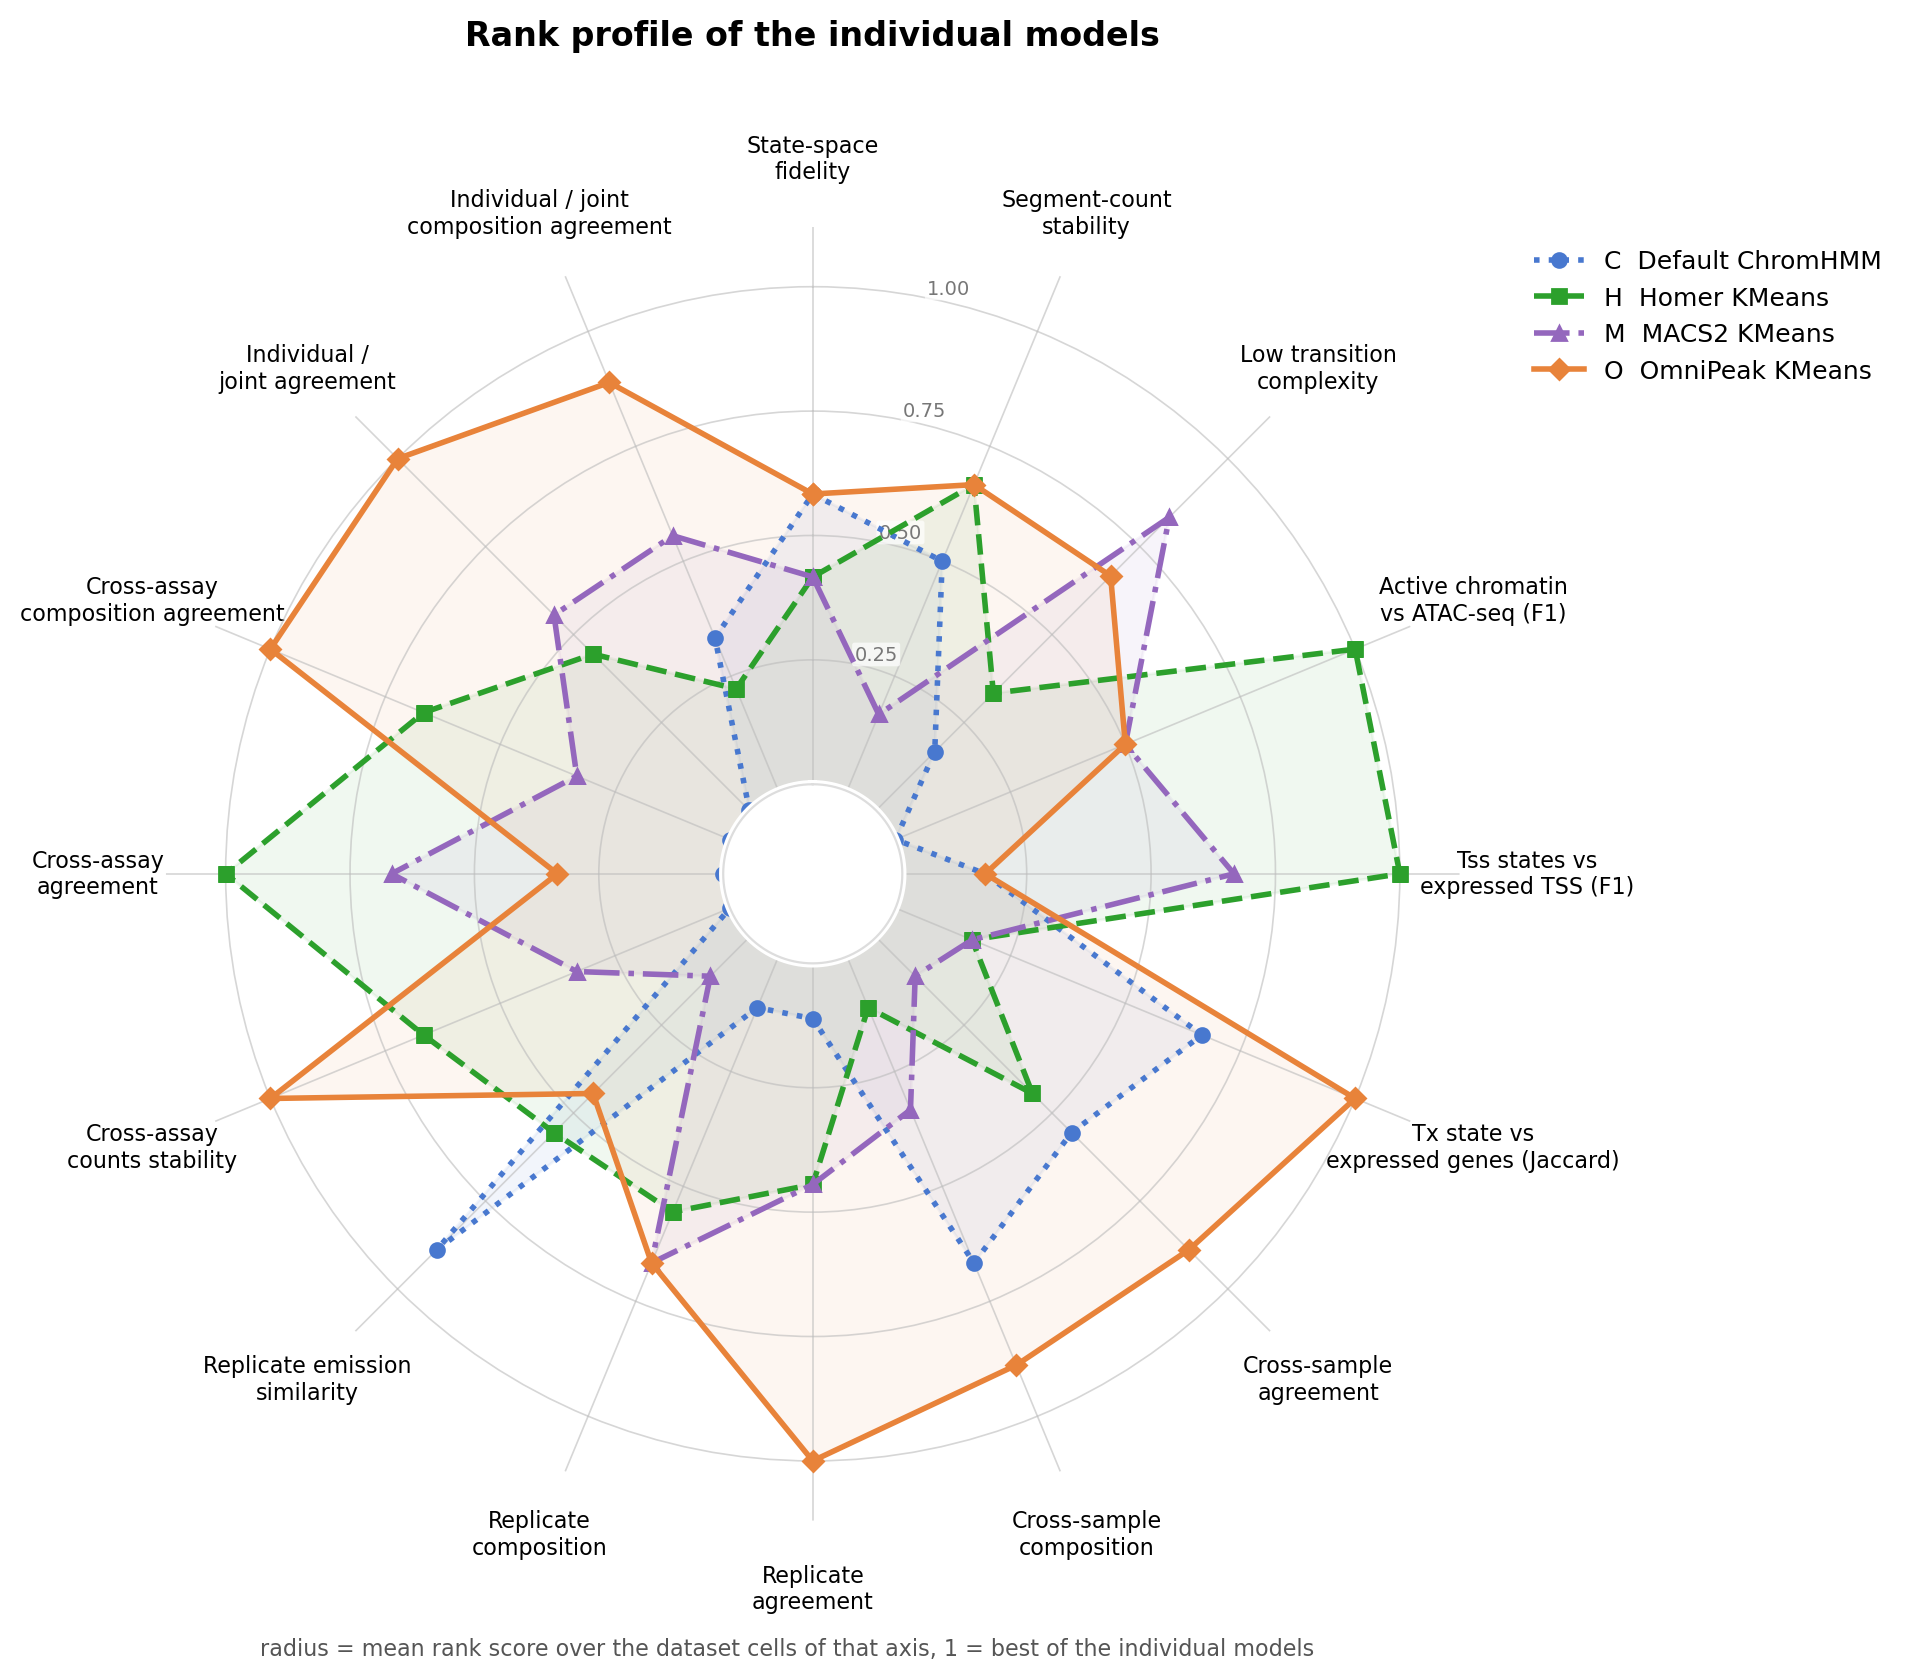

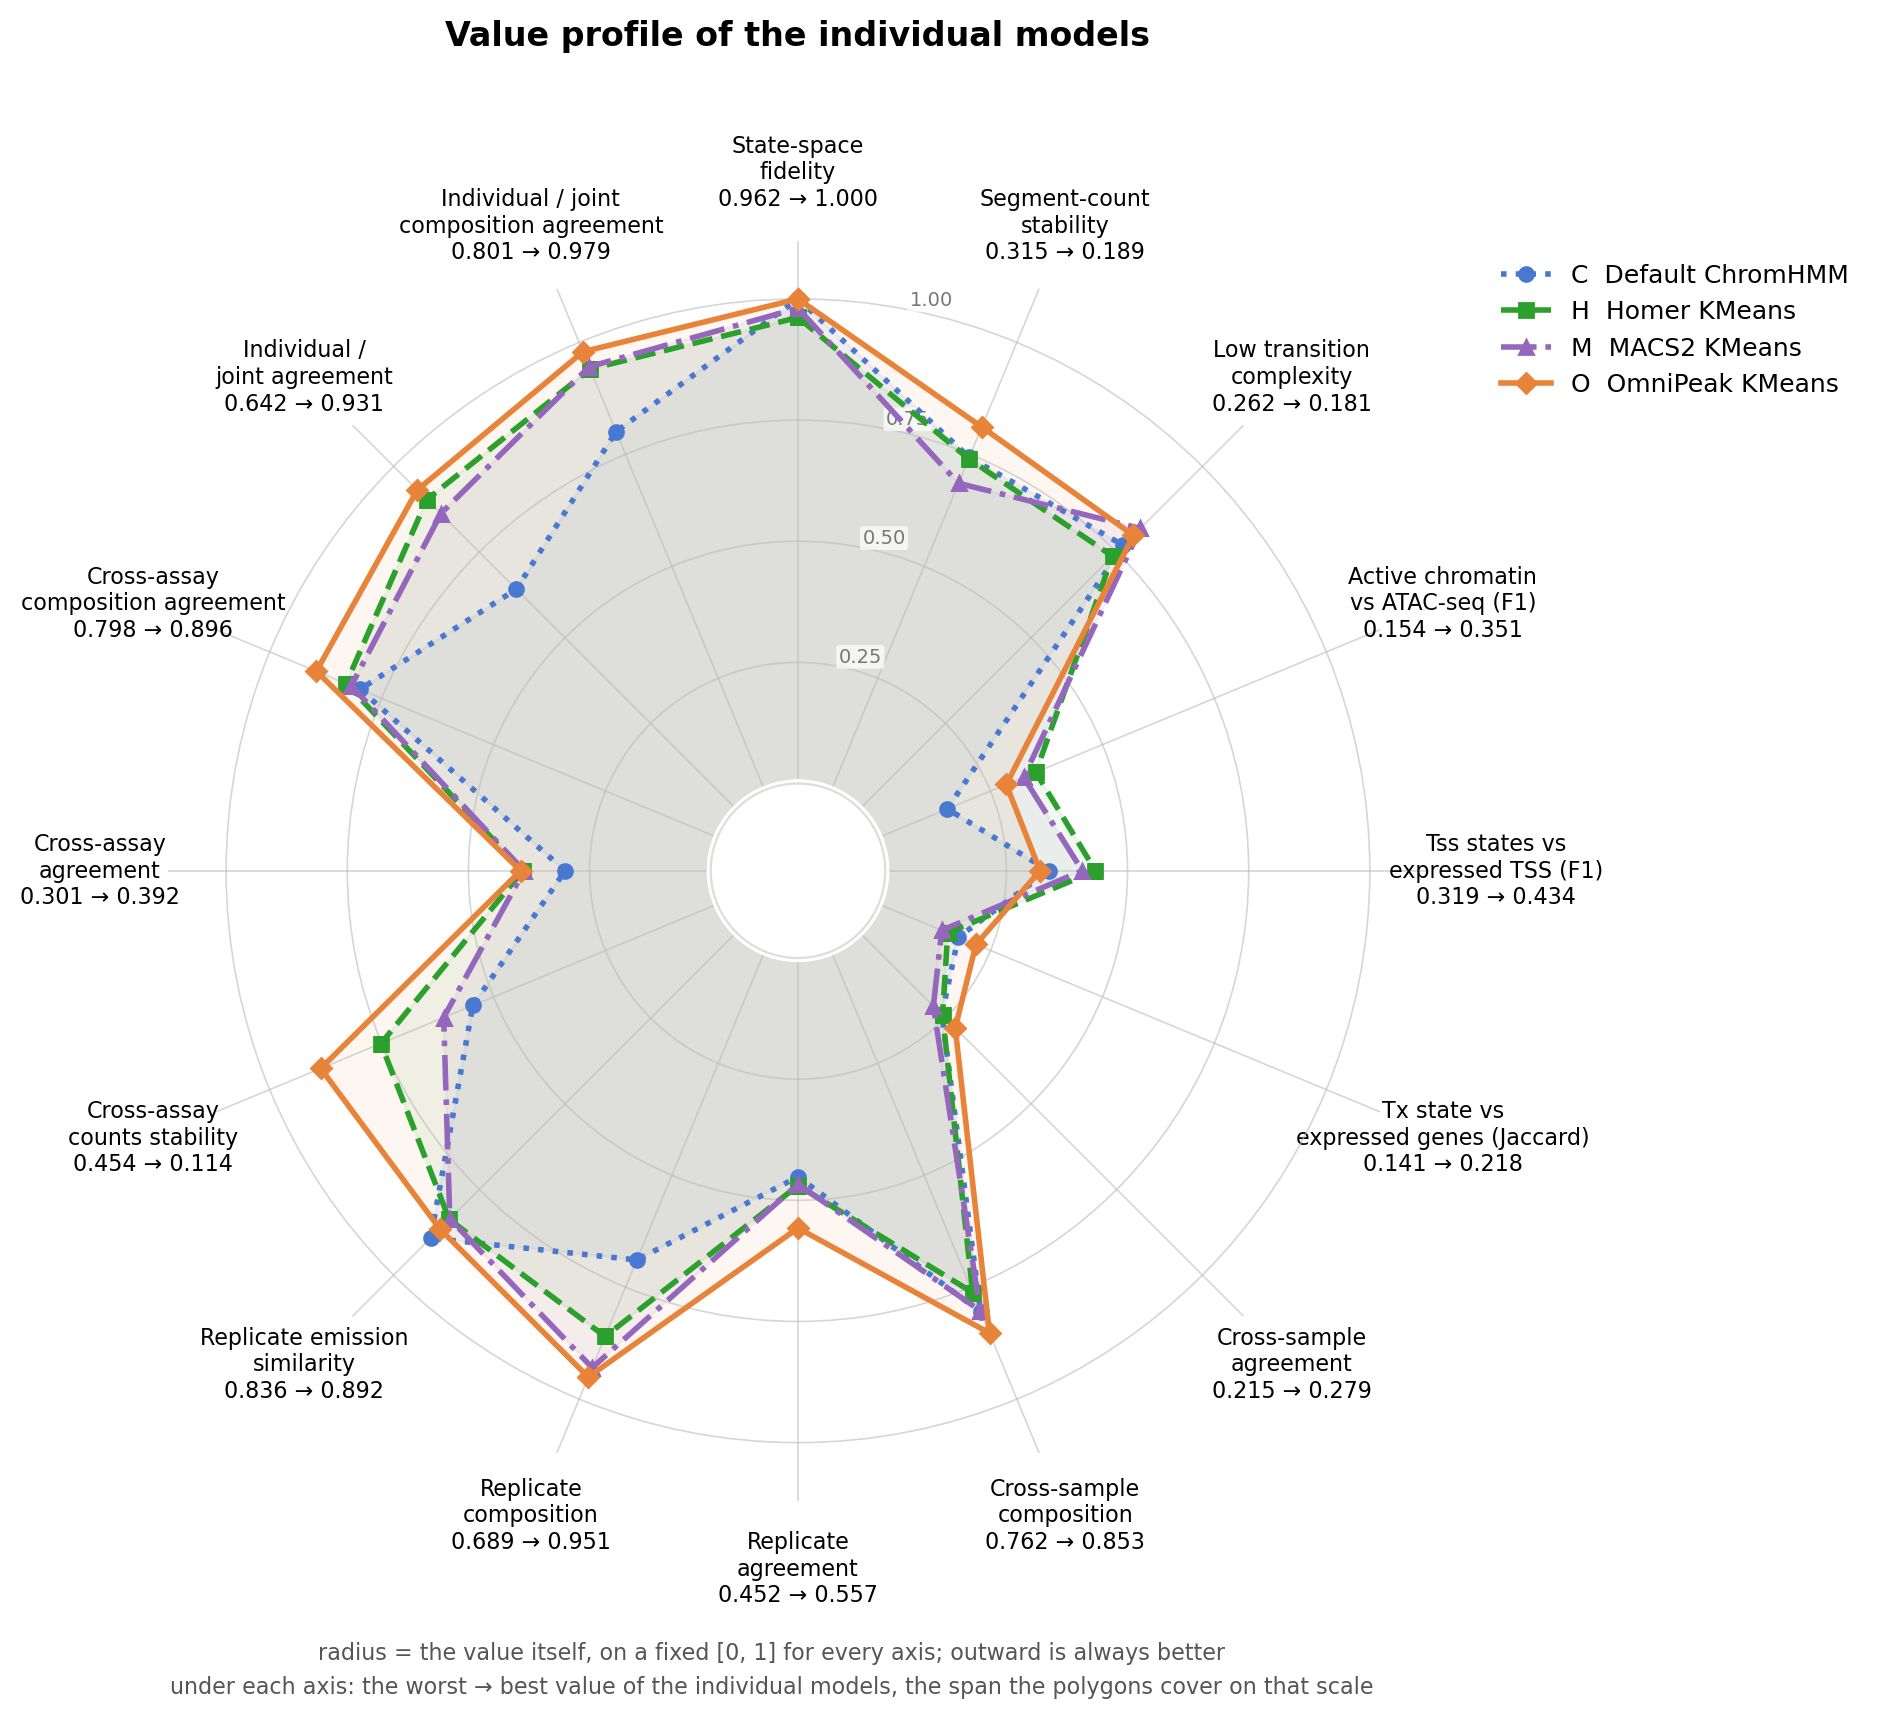

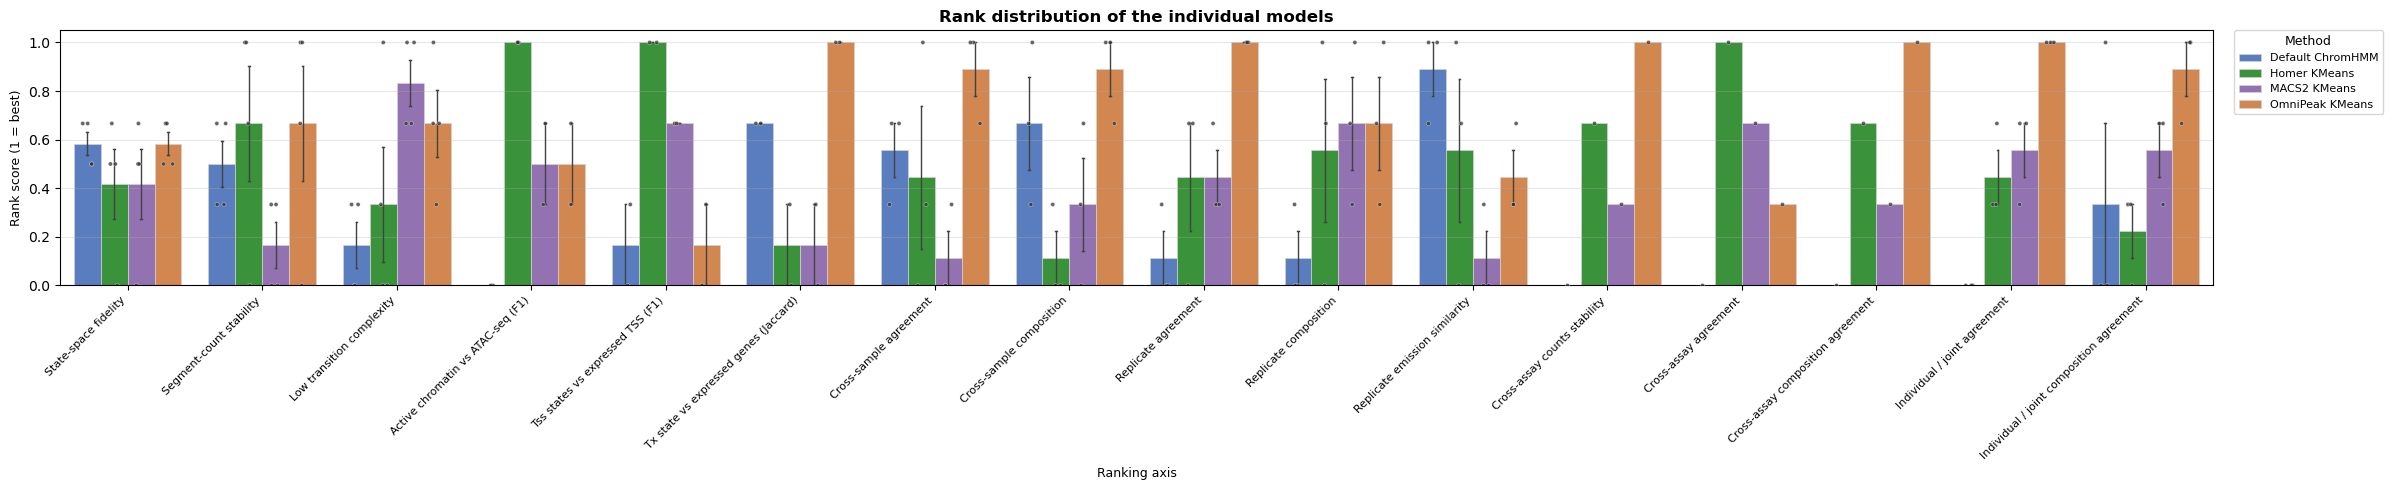

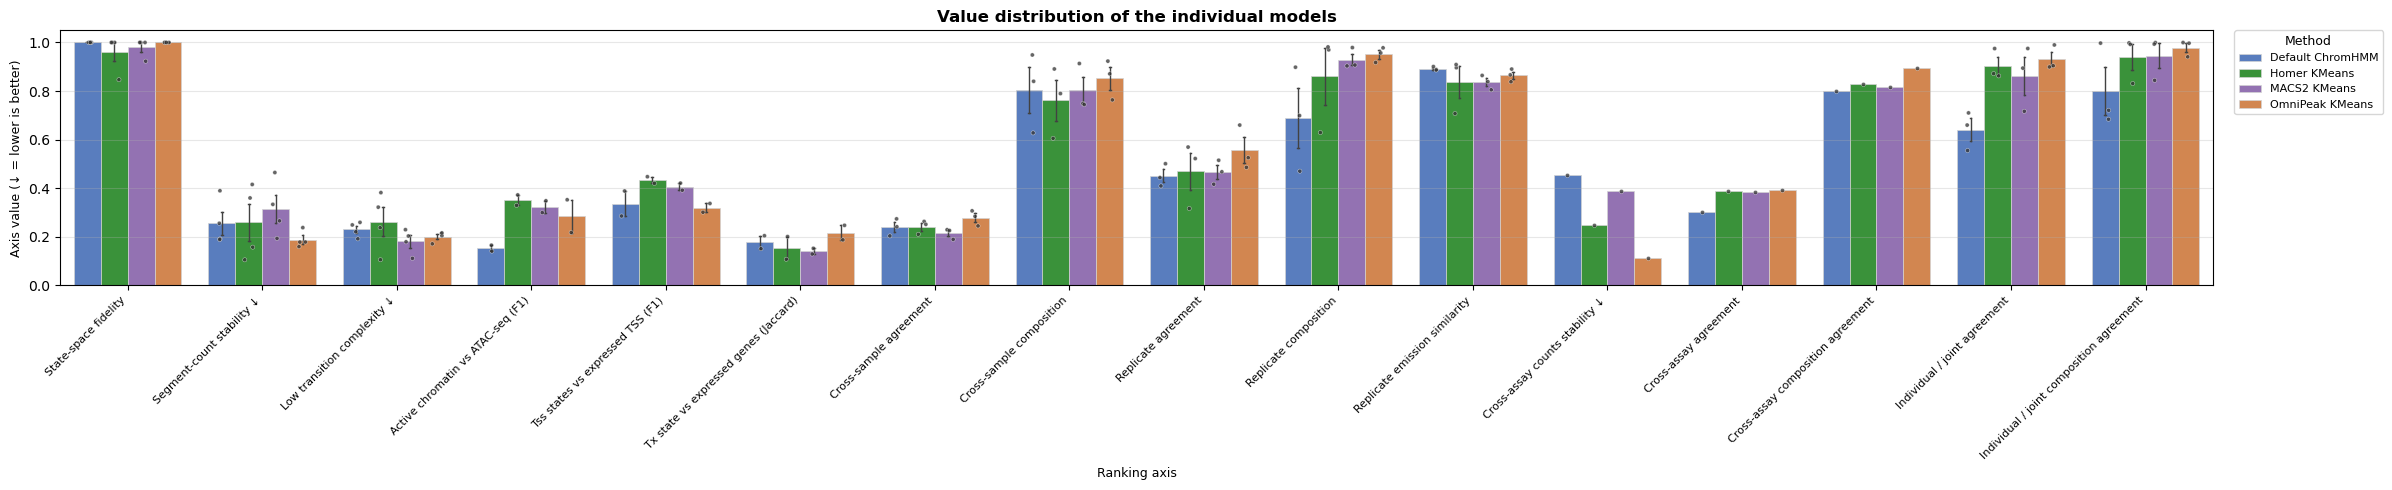

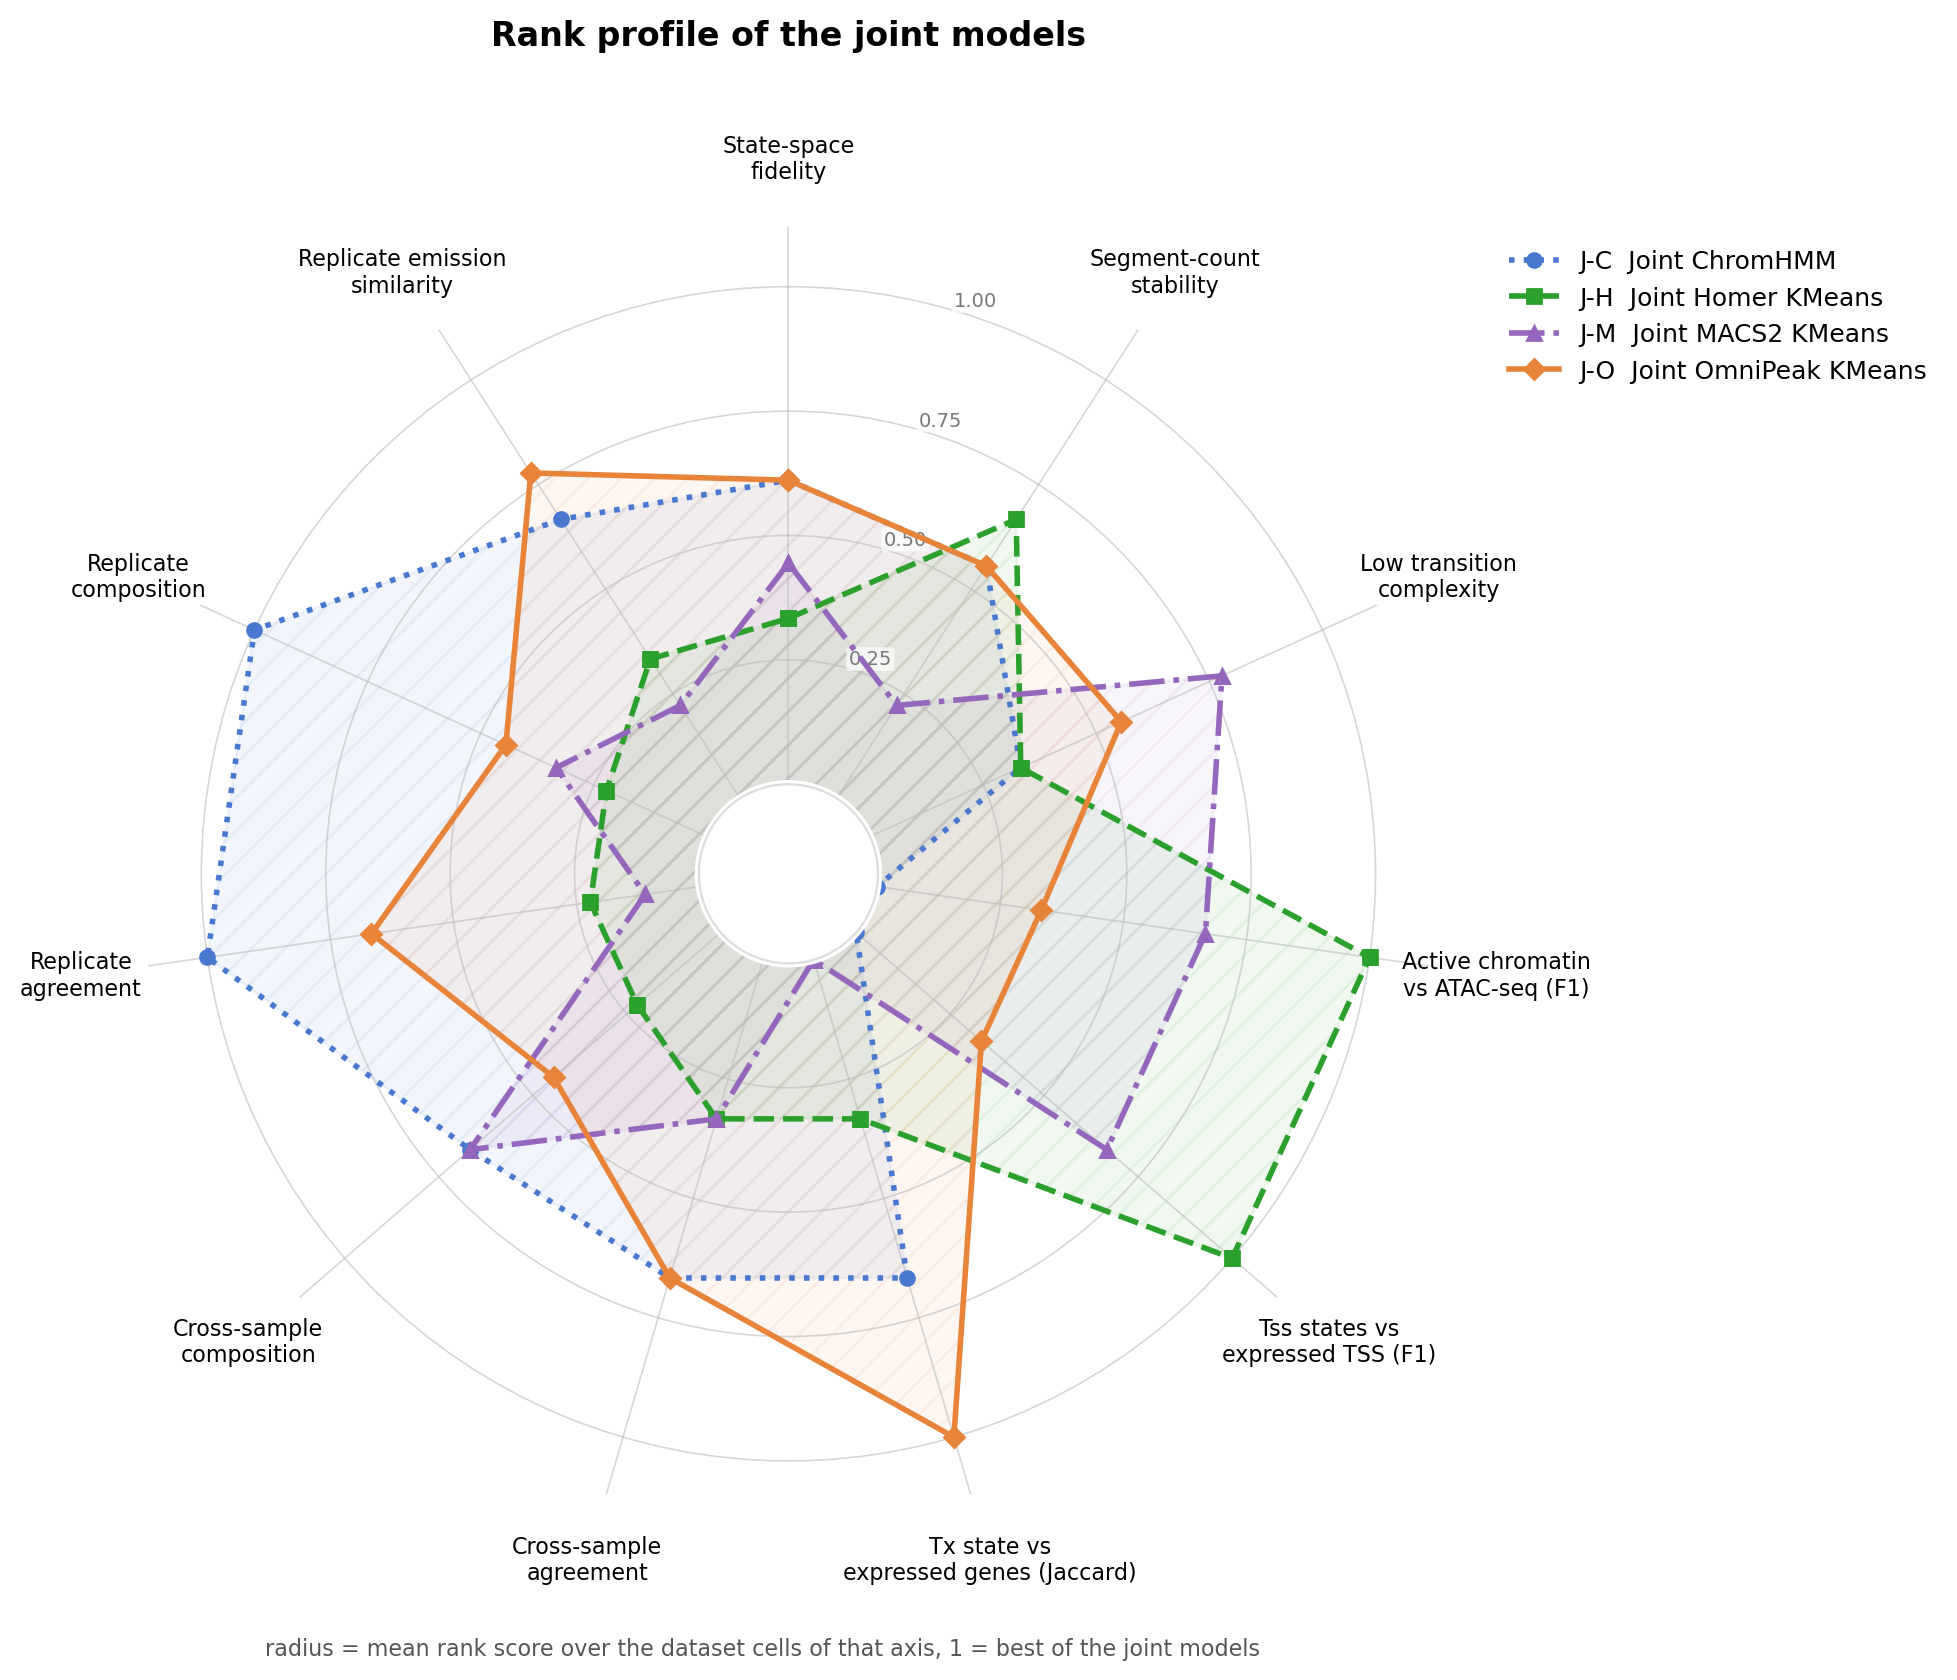

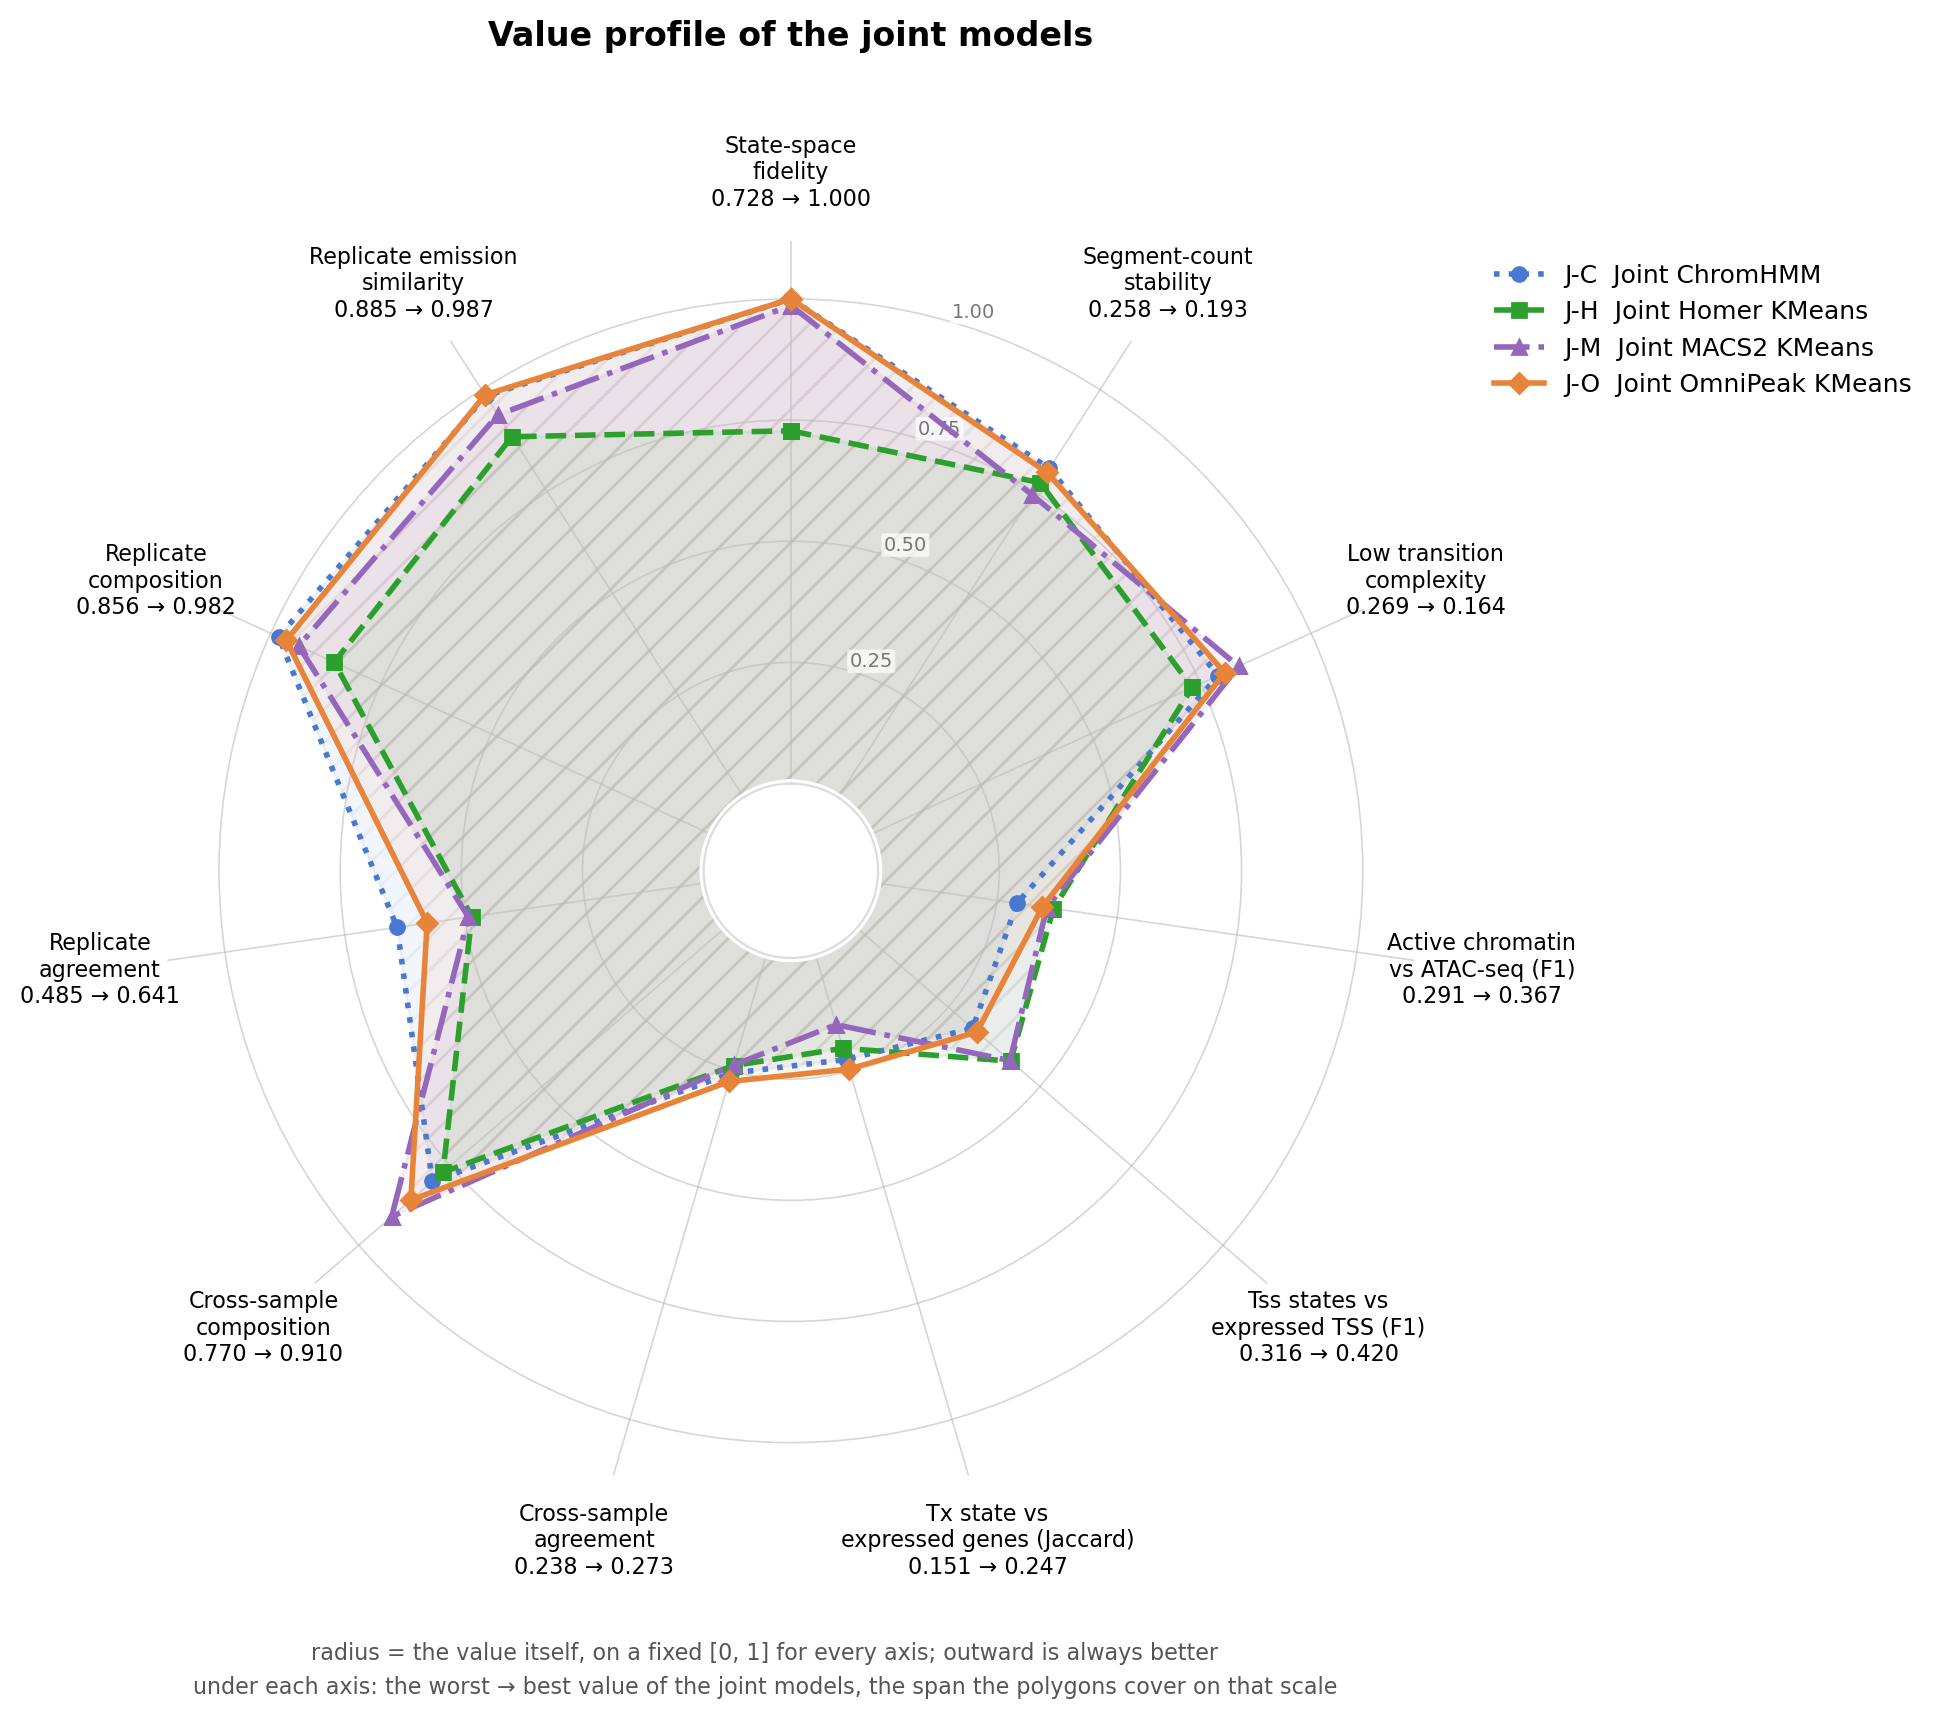

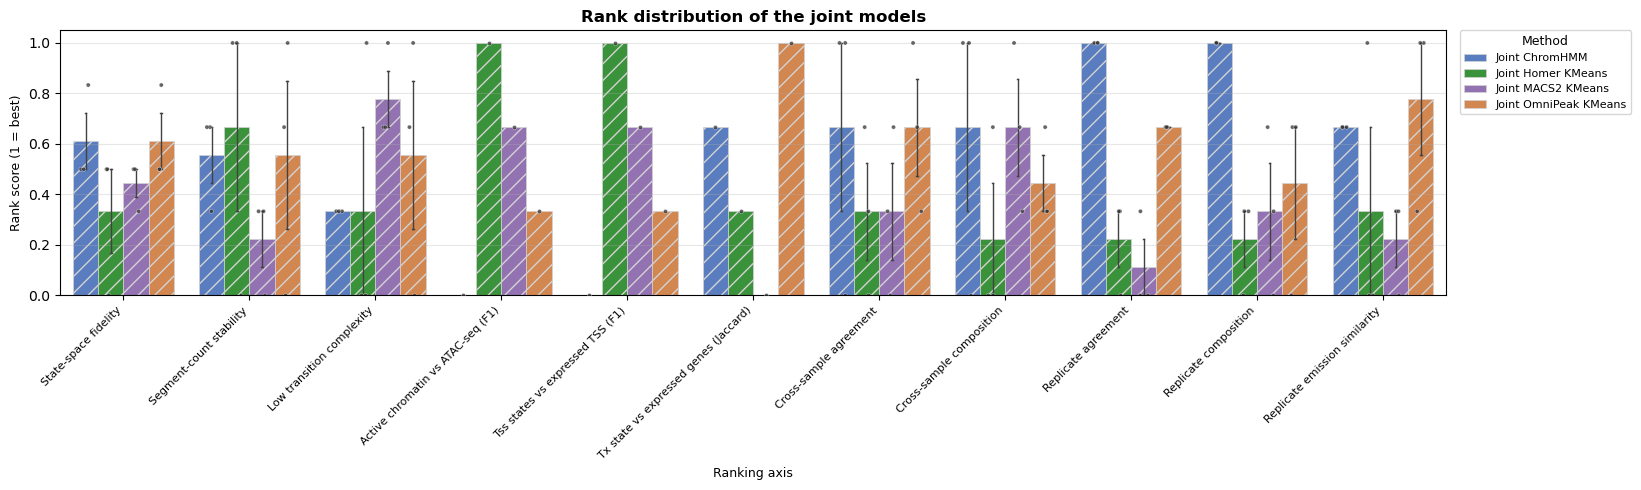

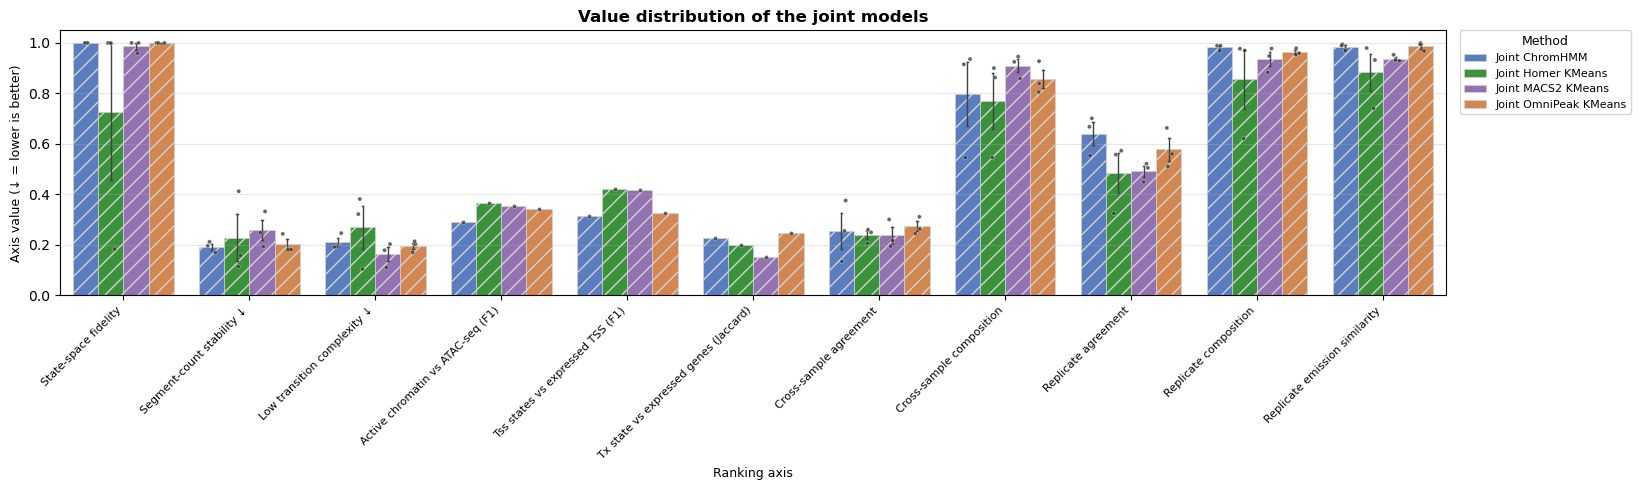

8

In [13]:
header("Rank profiles")
show_all(["radar_individual.png", "radar_values_individual.png",
          "radar_barplot_individual.png", "radar_values_barplot_individual.png",
          "radar_joint.png", "radar_values_joint.png",
          "radar_barplot_joint.png", "radar_values_barplot_joint.png"],
         base=OUT, width=900)

,Rank,Method,Score,Axes,Datasets,Best axis,Worst axis
Method,,,,,,,
kmeans_omni,1,OmniPeak KMeans,0.731,16,3,Tx state vs expressed genes (Jaccard),Tss states vs expressed TSS (F1)
kmeans_homer,2,Homer KMeans,0.543,16,3,Active chromatin vs ATAC-seq (F1),Cross-sample composition
kmeans_macs2,3,MACS2 KMeans,0.429,16,3,Low transition complexity,Cross-sample agreement
chromhmm_default,4,Default ChromHMM,0.297,16,3,Replicate emission similarity,Active chromatin vs ATAC-seq (F1)


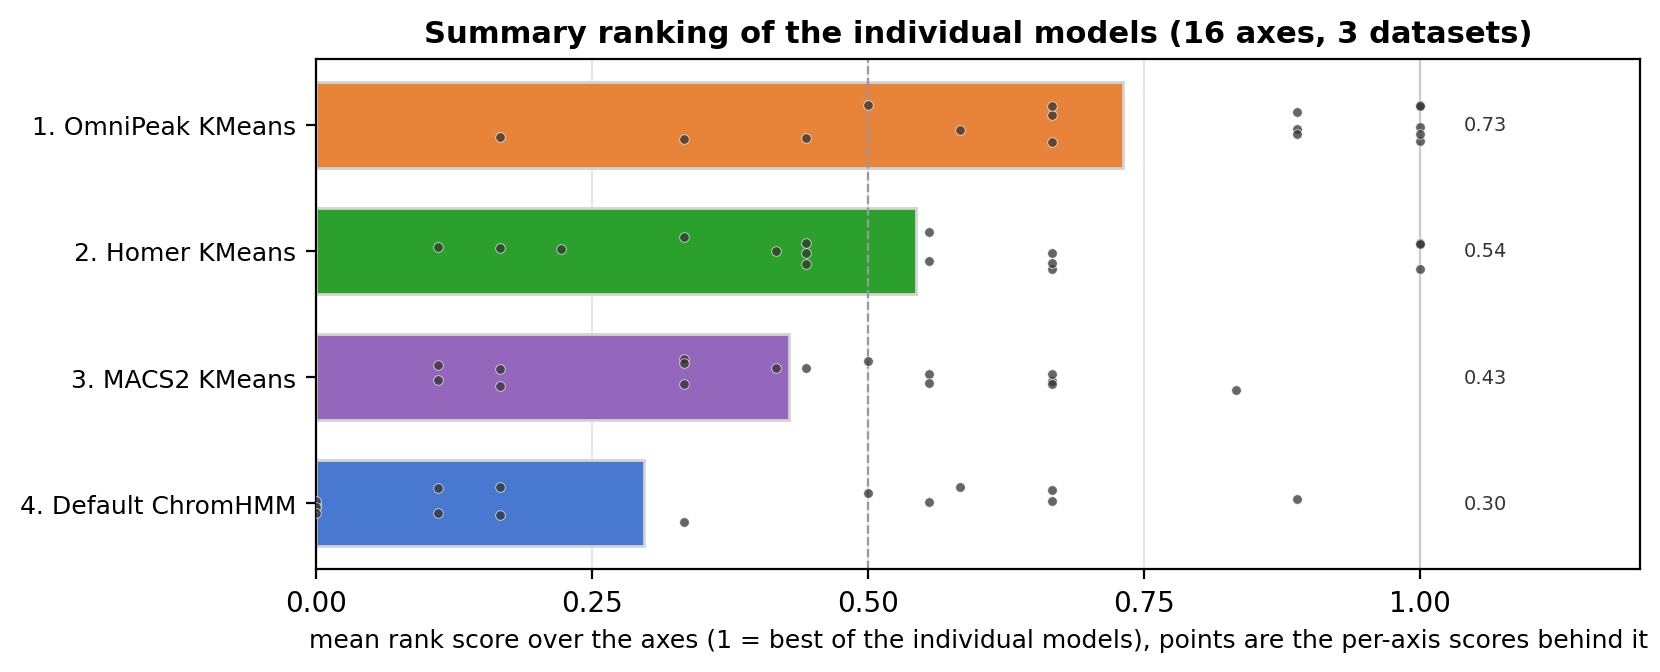

,Rank,Method,Score,Axes,Datasets,Best axis,Worst axis
Method,,,,,,,
joint_kmeans_omni,1,Joint OmniPeak KMeans,0.581,11,3,Tx state vs expressed genes (Jaccard),Active chromatin vs ATAC-seq (F1)
joint_chromhmm,2,Joint ChromHMM,0.561,11,3,Replicate agreement,Active chromatin vs ATAC-seq (F1)
joint_kmeans_homer,3,Joint Homer KMeans,0.455,11,3,Active chromatin vs ATAC-seq (F1),Cross-sample composition
joint_kmeans_macs2,4,Joint MACS2 KMeans,0.404,11,3,Low transition complexity,Tx state vs expressed genes (Jaccard)


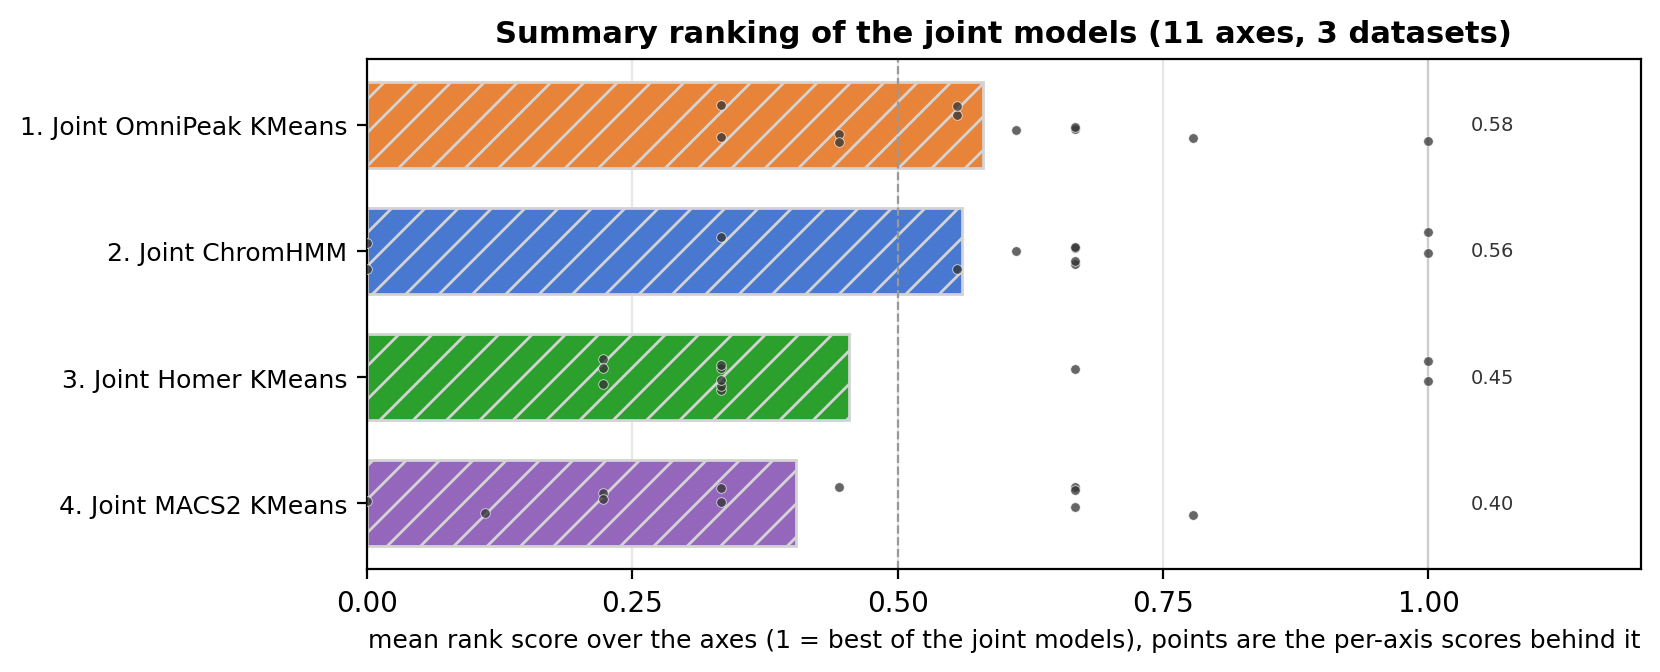

In [15]:
for group, ranking in [("individual", df_ranking_individual),
                       ("joint", df_ranking_joint)]:
    header(f"Summary ranking of the {group} models "
           f"({int(ranking['Axes'].max()) if not ranking.empty else 0} axes)")
    display(ranking.round(3))
    show_all([f"ranking_{group}.png"], base=OUT, width=820)